<a href="https://colab.research.google.com/github/RaquelHernanz/BachelorsThesis_SyntheticClinicalData/blob/master/NOTEBOOK10_BTSD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 10 — Privacy Evaluation: Re-identification and Membership Risk**

- **Author:** Raquel Hernanz Hernández
- **Supervisors:** José María Herrera and Guillermo José Ortega
- **Degree:** Biomedical Engineering
- **Project:** Bachelor Thesis — *Generation and Validation of Synthetic Data from a Hospital Emergency Department*

---

### Role in the pipeline

| Notebook | Purpose |
|----------|---------|
| NB8 | Fidelity and inter-replica stability evaluation |
| NB9 | Utility evaluation: TSTR, replicability framework |
| **NB10** | **Privacy evaluation: re-identification and membership risk** |

---

## Objectives

Evaluates the privacy risks of synthetic data generated by CTAB-GAN+ (**NB6**) and ARF/FORDE (**NB7**) through complementary tests:

1. **K-anonymity** — minimum equivalence class size in synthetic data
2. **NNAA** — Nearest Neighbour Adversarial Accuracy (bidirectional attack simulation)
3. **NND / NNDR** — nearest-neighbour distance distribution and near-copy detection
4. **Membership Disclosure** — El Emam corrected relative F1 metric using the partitioning attack
5. **Linkability** — QID-space NNDR uniqueness test
6. **DOMIAS** — density-ratio membership inference attack score
7. **Authenticity / Near-duplicates** — proportion of synthetic records too close to real training records
8. **Comparative summary** — privacy profile radar chart

### Key references

- Vallevik et al. 2024
- Qian et al. 2024
- El Emam et al. 2024
- Miletic & Sariyar (2025)


## Methodology Overview

This notebook applies a multi-layered privacy evaluation framework to assess
re-identification, near-copying and membership inference risks of the synthetic
data generated by CTAB-GAN+ (NB6) and ARF/FORDE (NB7).

### Evaluation dimensions

| Section | Test | Risk Category | Main Criterion |
|---------|------|---------------|----------------|
| 2 | K-anonymity | Re-identification descriptor | k_min ≥ 5 |
| 3 | NNAA | Membership/overfitting via nearest neighbours | ideal ≈ 0.50; risk > 0.60; fidelity warning < 0.40 |
| 4 | NND / NNDR | Near-copy detection | near-copy rate < 1 % |
| 5 | Membership Disclosure | Membership inference, El Emam partitioning attack | corrected F_rel ≤ 0.20 |
| 6 | Linkability | Re-identification via QID linkage | link rate < 5 % |
| 7 | DOMIAS | Density-ratio membership inference | AUC ≈ 0.50; warning > 0.55; risk > 0.60 |
| 8 | Authenticity | Near-duplicate detection | ≥ 0.95 |

### Data flow

```
GENERATION/DATASET_<GENERATOR>/
    ├── cohorts/              →  X_real      (real training reference, 2–8)
    ├── dataset_TEST.csv      →  X_holdout   (real non-member/test reference, 5 and 7)
    └── ds01–ds10/
            └── dataset_SYNTH_*.csv  →  X_synth per replica
```

`dataset_TEST.csv` is the preferred and methodologically correct holdout source,
matching NB9. Reconstruction from `dataset_FINAL.csv` is kept only as a fallback
for robustness.

### Cohort protocol

CTAB-GAN+ and ARF/FORDE use the same exported cohort-wise training protocol.
Therefore, for the same generation run, their real training references and their
synthetic replicas should have the same number of rows. The data-loading cell
checks this explicitly.

### Subsampling and distances

Nearest-neighbour computations use balanced subsampling
(n = `SUBSAMPLE_N`, default 500) with BallTree (Euclidean metric), consistent
with NB8. K-anonymity and Authenticity use all records without subsampling.

### Notes on interpretation

- **K-anonymity is not used alone.** It is one descriptor of re-identification
  risk and is interpreted together with linkability, NNDR, authenticity, DOMIAS,
  NNAA and membership disclosure.
- **Membership Disclosure** is implemented with El Emam's partitioning method:
  the attack dataset must contain training members in proportion
  `n_train / POPULATION_SIZE`, and the reported score is the corrected relative
  F1 improvement over the naive attacker.
- **DOMIAS** is implemented as a density ratio `log p_G(x) − log p_R(x)`, not
  as synthetic density alone.

### References

- Vallevik et al. (2024)
- Miletic & Sariyar (2025)
- Qian et al. (2024)
- El Emam et al. (2024)


## **1. Configuration**

In [ ]:
# ── LIBRARIES ─────────────────────────────────────────────────────────────────
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import BallTree, NearestNeighbors, KernelDensity
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict, StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score

warnings.filterwarnings('ignore')
np.random.seed(42)

print("Libraries loaded.")


Libraries loaded.


In [ ]:
# ── GLOBAL CONFIGURATION + DRIVE/PATH HANDLING ─────────────────────────────
# PURPOSE: Centralise all user-configurable parameters for the privacy
#          evaluation. Change GENERATOR to 'ARF' and re-run the entire
#          notebook for the second generator.

GENERATOR   = 'ARF'       # Run once with 'CTABGAN' and once with 'ARF'
N_REPLICAS  = 10
SUBSAMPLE_N = 500             # balanced subsampling for NN searches (NB8 precedent)

# ── Mount Google Drive if running in Colab ───────────────────────────────────
try:
    import google.colab
    from google.colab import drive
    if not Path('/content/drive/MyDrive').exists():
        drive.mount('/content/drive')
        print('Drive mounted.')
    else:
        print('Drive already mounted.')
except ImportError:
    print('Not running in Colab — skipping Drive mount.')

# ── Feature lists ─────────────────────────────────────────────────────────────
# Continuous/integer features used for distance computations.
# NOTE: O2 is binary (1=Yes, 2=No) — excluded from distance metrics.
#       GCS is ordinal (3-15) — included because it carries clinical magnitude.
#       GCS.O, GCS.V, GCS.M are sub-components — excluded to avoid redundancy.
#       Lactato is included once only; duplicated features would overweight a
#       variable in all distance/density-based metrics.
ALL_FEATURES = [
    'Edad', 'GCS', 'Lactato', 'TT', 'FR', 'SpO2', 'FiO2',
    'FC', 'TAS', 'TAD', 'TAM', 'Glucemia'
]

# Quasi-identifiers for K-anonymity and linkability (key vitals)
QUASI_IDS = ['Edad', 'GCS', 'FR', 'SpO2']

# ── Thresholds ────────────────────────────────────────────────────────────────
NNDR_THRESHOLD       = 0.50    # NNDR < 0.5 -> near-copy flag [N3A]
NEARDUP_PERCENTILE   = 5       # 5th percentile of positive real-to-real NND
NNAA_LOW_THR         = 0.40    # NNAA < 0.40 -> fidelity/mixing warning
NNAA_RISK_THR        = 0.60    # NNAA > 0.60 -> privacy risk
MD_THRESHOLD         = 0.20    # Corrected El Emam F_rel threshold [N1E/JAMIA Open 2022]
MD_N_BINS            = 10      # Quantile bins for Hamming-based partitioning attack
MD_HAMMING_THRESHOLD = 1       # Max number of mismatched binned features to call a match
MD_ATTACK_SIZE       = 20_000  # Base size for simulated attack dataset
MD_MIN_POSITIVES     = 25      # Stabilise F1 when n_train / population is tiny
LINK_THRESHOLD       = 0.50    # QID-NNDR < 0.5 -> unique linkage flag [N3D]
DOMIAS_WARN_THR      = 0.55    # DOMIAS AUC > 0.55 -> warning
DOMIAS_RISK_THR      = 0.60    # DOMIAS AUC > 0.60 -> privacy risk [N4A]
DOMIAS_REF_FRACTION  = 0.50    # Fraction of holdout used to estimate p_R in DOMIAS

# Membership disclosure: population size for the naive attacker prior.
# Set to approximate catchment population.
POPULATION_SIZE = 1_364_952

# ── Paths (same mounting/diagnostic pattern as NB8/NB9) ──────────────────────
TFG_ROOT = Path('/content/drive/MyDrive/Colab Notebooks/TFG')
CONTENT_ROOT = Path('/content/')
GEN_DIR  = TFG_ROOT / 'GENERATION'
BASE_GEN = {
    'CTABGAN': GEN_DIR / 'DATASET_CTABGAN',
    'ARF':     GEN_DIR / 'DATASET_ARF',
}
SYNTH_FILENAME = {
    'CTABGAN': 'dataset_SYNTH_CTABGAN.csv',
    'ARF':     'dataset_SYNTH_ARF.csv',
}
OUTPUT_DIR = TFG_ROOT / 'EVALUATION' / 'NB10_PRIVACY' / GENERATOR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

gen_base = BASE_GEN[GENERATOR]

# Primary test/holdout source: same generator-specific dataset_TEST.csv used in NB9.
_TEST_CANDIDATES = [
    gen_base / 'dataset_TEST.csv',
    TFG_ROOT / 'dataset_TEST.csv',
    GEN_DIR  / 'dataset_TEST.csv',
]
TEST_PATH = next((p for p in _TEST_CANDIDATES if p.exists()), None)

# Fallback path only used if dataset_TEST.csv is unavailable.
_ORIG_CANDIDATES = [
    CONTENT_ROOT / 'dataset_FINAL.csv',
    TFG_ROOT / 'dataset_FINAL.csv',
    GEN_DIR  / 'dataset_FINAL.csv',
    BASE_GEN['CTABGAN'] / 'dataset_FINAL.csv',
    BASE_GEN['ARF']     / 'dataset_FINAL.csv',
]
ORIG_PATH = next((p for p in _ORIG_CANDIDATES if p.exists()), None)

required_paths = {
    'Generator dir'    : gen_base,
    'Metadata'         : gen_base / 'generation_metadata.json',
    'Cohorts dir'      : gen_base / 'cohorts',
}

print('\n── Path diagnostic ──────────────────────────────────────────────────')
all_ok = True
for label, p in required_paths.items():
    found = Path(p).exists()
    print(f"  {'✓' if found else '✗ MISSING'}  {label:<16} {p}")
    if not found:
        all_ok = False

print(f"  {'✓' if TEST_PATH else '⚠ fallback'}  dataset_TEST.csv {TEST_PATH or _TEST_CANDIDATES[0]}")
print(f"  {'✓' if ORIG_PATH else '⚠ optional'}  dataset_FINAL.csv {ORIG_PATH or _ORIG_CANDIDATES[0]}")

if TEST_PATH is None and ORIG_PATH is None:
    all_ok = False
    print('  ✗ MISSING  Neither dataset_TEST.csv nor dataset_FINAL.csv is available.')

if gen_base.exists():
    ds_dirs = sorted(d for d in os.listdir(gen_base)
                     if d.startswith('ds') and (gen_base / d).is_dir())
    print(f"  {'✓' if ds_dirs else '✗'}  Replicas found    : {ds_dirs if ds_dirs else 'NONE'}")
    if len(ds_dirs) < N_REPLICAS:
        all_ok = False
        print(f"  ✗ MISSING  Requested {N_REPLICAS} replicas but only {len(ds_dirs)} found.")
else:
    ds_dirs = []

print('─────────────────────────────────────────────────────────────────────')

if not all_ok:
    raise FileNotFoundError(
        'One or more required NB10 paths are missing (see ✗ above).\n'
        'Check that:\n'
        '  1. Google Drive is mounted at /content/drive.\n'
        '  2. NB6/NB7 exported dsXX/, cohorts/ and generation_metadata.json.\n'
        '  3. dataset_TEST.csv exists in the selected DATASET_<GENERATOR>/ folder.\n'
        '  4. If dataset_TEST.csv is unavailable, dataset_FINAL.csv must exist for fallback reconstruction.\n'
        '  5. The TFG_ROOT path matches your Drive folder structure.'
    )

print(f'Generator      : {GENERATOR}')
print(f'All features   : {ALL_FEATURES}')
print(f'Quasi-IDs      : {QUASI_IDS}')
print(f'Population size: {POPULATION_SIZE:,}')
print(f'Test path      : {TEST_PATH}')
print(f'Output dir     : {OUTPUT_DIR}')


Drive already mounted.

── Path diagnostic ──────────────────────────────────────────────────
  ✓  Generator dir    /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF
  ✓  Metadata         /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/generation_metadata.json
  ✓  Cohorts dir      /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/cohorts
  ✓  dataset_TEST.csv /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/dataset_TEST.csv
  ✓  dataset_FINAL.csv /content/dataset_FINAL.csv
  ✓  Replicas found    : ['ds01', 'ds02', 'ds03', 'ds04', 'ds05', 'ds06', 'ds07', 'ds08', 'ds09', 'ds10']
─────────────────────────────────────────────────────────────────────
Generator      : ARF
All features   : ['Edad', 'GCS', 'Lactato', 'TT', 'FR', 'SpO2', 'FiO2', 'FC', 'TAS', 'TAD', 'TAM', 'Glucemia']
Quasi-IDs      : ['Edad', 'GCS', 'FR', 'SpO2']
Population size: 1,364,952
Test path      : /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/D

In [ ]:
# ── TFG UNIFIED PLOT STYLE ────────────────────────────────────────────────────
# PURPOSE: Set a consistent visual identity across all NB10 plots,
#          matching the style established in NB6-NB9.

# Aligned with NB8 TFG_STYLE for cross-notebook visual consistency.
TFG_STYLE = {
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    'black',
    'axes.linewidth':    0.8,
    'axes.grid':         True,
    'grid.color':        '#d9d9d9',
    'grid.linewidth':    0.5,
    'grid.linestyle':    '-',
    'font.family':       'serif',
    'font.serif':        ['DejaVu Serif', 'Times New Roman', 'serif'],
    'font.size':         11,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   9,
    'legend.frameon':    True,
    'legend.framealpha': 0.9,
    'legend.edgecolor':  '#cccccc',
    'xtick.direction':   'out',
    'ytick.direction':   'out',
    'xtick.major.size':  4,
    'ytick.major.size':  4,
    'figure.dpi':        100,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
}
plt.rcParams.update(TFG_STYLE)

TFG_COLORS = {
    'CTABGAN': '#2C5F8A',
    'ARF':     '#E07B39',
    'real':    '#CC0000',
    'neutral': '#888888',
}

print("Plot style set.")

Plot style set.


## **2. Data Loading**

For privacy evaluation the relevant real reference depends on the test:

- **Training reference (`df_real`)**: exported cohort files in `cohorts/`. These
  are the records seen by the generator and are therefore the correct reference
  for near-copy, linkability, authenticity and membership-risk tests.
- **Holdout / non-member reference (`df_holdout`)**: `dataset_TEST.csv` from the
  selected generator folder. This is the real test partition not used to train
  the generator, matching the NB9 TSTR setup.

The notebook therefore avoids comparing against the full `dataset_FINAL.csv`
unless it must reconstruct a missing holdout as a fallback.

### Key objects produced

| Object | Type | Description |
|--------|------|-------------|
| `replicas` | `dict[str, DataFrame]` | 10 synthetic replicas (ds01–ds10) |
| `df_real` | `DataFrame` | Real training reference from exported cohorts |
| `df_holdout` | `DataFrame` | Real non-member/test reference from `dataset_TEST.csv` |
| `X_real` | `ndarray` | Imputed + StandardScaled real training matrix |
| `X_holdout` | `ndarray` | Imputed + StandardScaled real holdout matrix |
| `X_synth_all` | `ndarray` | Pooled synthetic matrix (all replicas) |
| `imp` | `SimpleImputer(strategy='median')` | Fitted on real training data only |
| `scaler` | `StandardScaler()` | Fitted on real training data only |
| `AVAIL_FEATURES` | `list[str]` | De-duplicated available feature list |
| `AVAIL_QIDS` | `list[str]` | Available quasi-identifier list |

> **Important:** `imp` and `scaler` are fitted **only on the real training data**.
> Synthetic and holdout records are transformed via `.transform()`, never
> `.fit_transform()`, to avoid leakage into the preprocessing pipeline.


In [ ]:
# ── DATA LOADING ──────────────────────────────────────────────────────────────
# PURPOSE: Load synthetic replicas, the real training reference, and the real
#          held-out test partition used by DOMIAS and Membership Disclosure.
#
# LOGIC (aligned with NB8/NB9):
#   1. Load synthetic replicas from dsXX/.
#   2. Prefer the exact saved training cohorts in gen_dir/cohorts/.
#   3. Load the held-out real partition from gen_dir/dataset_TEST.csv.
#   4. Only if dataset_TEST.csv is unavailable, fall back to test/ or
#      reconstruction from dataset_FINAL.csv + generation_metadata.json.
#
# Both CTAB-GAN+ and ARF/FORDE follow the same cohort-wise train/test protocol;
# therefore their real training reference and synthetic replicas should have
# the same number of rows for the same generation run.

gen_base = Path(BASE_GEN[GENERATOR])
fname    = SYNTH_FILENAME[GENERATOR]


def _read_csv_clean(path):
    """Read a CSV and standardise column names."""
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'File not found: {path}')
    df = pd.read_csv(path)
    df.columns = df.columns.astype(str).str.strip()
    return df


def safe_features(df, feature_list):
    """Return the de-duplicated subset of ``feature_list`` present in ``df``.

    Preserves the order of ``feature_list`` and reports any duplicated entries
    to stdout. Features absent from ``df`` are silently dropped.

    Parameters
    ----------
    df : pd.DataFrame
        Reference DataFrame; column names are checked against it.
    feature_list : list of str
        Candidate feature names, possibly with duplicates.

    Returns
    -------
    list of str
        Subset of ``feature_list`` whose names appear in ``df.columns``, with
        duplicates removed and original order preserved.
    """
    seen = set()
    out = []
    duplicates = []
    for f in feature_list:
        if f in seen:
            duplicates.append(f)
            continue
        seen.add(f)
        if f in df.columns:
            out.append(f)
    if duplicates:
        print(f"!! WARNING: duplicated feature(s) removed: {sorted(set(duplicates))}")
    return out


def load_generation_metadata(gen_dir):
    """Load ``generation_metadata.json`` from a generator output directory.

    Parameters
    ----------
    gen_dir : str or Path
        Root directory of the generator output (e.g. ``DATASET_CTABGAN/``).

    Returns
    -------
    dict
        Parsed metadata dictionary.

    Raises
    ------
    FileNotFoundError
        If the metadata file does not exist.
    """
    path = Path(gen_dir) / 'generation_metadata.json'
    if not path.exists():
        raise FileNotFoundError(f'generation_metadata.json not found: {path}')
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def load_train_ref_from_cohorts(gen_dir):
    """Load the real training reference from ``gen_dir/cohorts/`` CSVs.

    NB6 and NB7 save each cohort's training split as a separate CSV inside a
    ``cohorts/`` subfolder. Reading these files directly is the safest way to
    reconstruct ``df_real``, because it avoids re-splitting with slightly
    different parameters.

    Parameters
    ----------
    gen_dir : str or Path
        Root directory of the generator output.

    Returns
    -------
    pd.DataFrame or None
        Concatenation of all cohort CSVs found in ``cohorts/``, or ``None``
        if the directory does not exist or contains no CSV files.
    """
    cohorts_dir = Path(gen_dir) / 'cohorts'
    if (not cohorts_dir.exists()) or (not cohorts_dir.is_dir()):
        return None

    csv_files = sorted(f for f in os.listdir(cohorts_dir) if f.endswith('.csv'))
    if not csv_files:
        return None

    parts = []
    for fname_local in csv_files:
        path = cohorts_dir / fname_local
        df = _read_csv_clean(path)
        parts.append(df)
        print(f'    {fname_local:<40}  n = {len(df)}')

    return pd.concat(parts, ignore_index=True)


def reconstruct_train_ref_population(orig_path, metadata):
    """Reconstruct the real training reference from ``dataset_FINAL.csv``.

    Fallback path used only when ``cohorts/`` is missing. Applies the same
    cohort-wise train/test split and survivor cap recorded in ``metadata``,
    then concatenates the four exclusive cohorts into a single population-level
    DataFrame.

    Parameters
    ----------
    orig_path : str or Path
        Path to ``dataset_FINAL.csv``.
    metadata : dict
        Parsed ``generation_metadata.json`` of the generator.

    Returns
    -------
    pd.DataFrame
        Concatenation of all four exclusive training cohorts.
    """
    df_full = _read_csv_clean(orig_path)

    split_cfg   = metadata['split']
    random_seed = split_cfg['random_seed']
    train_ratio = split_cfg['train_ratio']
    min_size    = split_cfg['min_size']

    cohort_filters = {
        'Mort. 2D':  lambda d: d[d['Mort. 2D'] == 1],
        'Mort. 7D':  lambda d: d[(d['Mort. 7D'] == 1) & (d['Mort. 2D'] == 0)],
        'Mort. 30D': lambda d: d[(d['Mort. 30D'] == 1) & (d['Mort. 7D'] == 0)],
        'survivors': lambda d: d[
            (d['Mort. 2D'] == 0) & (d['Mort. 7D'] == 0) & (d['Mort. 30D'] == 0)
        ],
    }

    parts = []
    for cohort_name, fn in cohort_filters.items():
        cohort_df = fn(df_full).reset_index(drop=True)
        if len(cohort_df) < min_size:
            train_df = cohort_df
        else:
            train_df, _ = train_test_split(
                cohort_df, train_size=train_ratio,
                random_state=random_seed, shuffle=True
            )

        expected_train = (
            metadata.get('cohorts', {})
                    .get(cohort_name, {})
                    .get('n_train', None)
        )

        if expected_train is None:
            expected_train = (
                metadata.get('cohort_sizes', {})
                        .get(cohort_name, {})
                        .get('n_train', None)
            )
        if expected_train is None:
            expected_train = (
                metadata.get('cohort_sizes', {})
                        .get(cohort_name, {})
                        .get('train', None)
            )

        if expected_train is not None and len(train_df) > expected_train:
            cap_seed = (metadata.get('survivors', {}).get('cap_seed', random_seed)
                        if cohort_name == 'survivors' else random_seed)
            train_df = train_df.sample(
                n=expected_train, random_state=cap_seed, replace=False
            ).reset_index(drop=True)

        parts.append(train_df)
        print(f"  {cohort_name:<12}  n_train = {len(train_df):>5}")

    return pd.concat(parts, ignore_index=True)


def load_train_ref(gen_dir, metadata, orig_path):
    """Load the real training reference, preferring saved cohort CSVs.

    Tries ``gen_dir/cohorts/`` first (exact training records seen by the
    generator). Falls back to ``reconstruct_train_ref_population`` when the
    cohort folder is absent or empty.

    Parameters
    ----------
    gen_dir : str or Path
        Generator output directory.
    metadata : dict
        Parsed ``generation_metadata.json``.
    orig_path : str or Path
        Path to ``dataset_FINAL.csv`` (used only on the fallback path).

    Returns
    -------
    pd.DataFrame
        Real training reference.

    Raises
    ------
    FileNotFoundError
        If neither ``cohorts/`` nor a usable ``orig_path`` is available.
    """
    df = load_train_ref_from_cohorts(gen_dir)
    if df is not None:
        print(f'  -> loaded from cohorts/  (total: {len(df)} rows)')
        return df

    if orig_path is None:
        raise FileNotFoundError('cohorts/ not found and dataset_FINAL.csv fallback is unavailable.')

    print(f'  -> cohorts/ not found or empty in {gen_dir}; reconstructing train_ref from dataset_FINAL.csv')
    return reconstruct_train_ref_population(orig_path, metadata)


def reconstruct_holdout_ref(orig_path, metadata):
    """Reconstruct the holdout reference as the complement of the train split.

    Used only when ``dataset_TEST.csv`` is unavailable. Cohorts smaller than
    ``min_size`` are skipped (they were not split during generation).

    Parameters
    ----------
    orig_path : str or Path
        Path to ``dataset_FINAL.csv``.
    metadata : dict
        Parsed ``generation_metadata.json`` of the generator.

    Returns
    -------
    pd.DataFrame
        Concatenation of the held-out portion of each cohort; empty if no
        cohort was eligible.
    """
    if orig_path is None:
        raise FileNotFoundError('dataset_FINAL.csv is required to reconstruct holdout.')

    df_full     = _read_csv_clean(orig_path)
    split_cfg   = metadata['split']
    random_seed = split_cfg['random_seed']
    train_ratio = split_cfg['train_ratio']
    min_size    = split_cfg['min_size']

    cohort_filters = {
        'Mort. 2D':  lambda d: d[d['Mort. 2D'] == 1],
        'Mort. 7D':  lambda d: d[(d['Mort. 7D'] == 1) & (d['Mort. 2D'] == 0)],
        'Mort. 30D': lambda d: d[(d['Mort. 30D'] == 1) & (d['Mort. 7D'] == 0)],
        'survivors': lambda d: d[
            (d['Mort. 2D'] == 0) & (d['Mort. 7D'] == 0) & (d['Mort. 30D'] == 0)
        ],
    }

    parts = []
    for name, fn in cohort_filters.items():
        cohort_df = fn(df_full).reset_index(drop=True)
        if len(cohort_df) < min_size:
            continue
        _, holdout_df = train_test_split(
            cohort_df, train_size=train_ratio,
            random_state=random_seed, shuffle=True
        )
        parts.append(holdout_df.reset_index(drop=True))
        print(f'    {name:<12}  n_holdout = {len(holdout_df):>4}')

    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()


def load_holdout_ref(gen_dir, metadata, test_path=None, orig_path=None):
    """Load the real held-out records used by DOMIAS and Membership Disclosure.

    Resolution order:
        1. ``test_path`` (typically the generator-specific
           ``DATASET_<GEN>/dataset_TEST.csv``, matching NB9).
        2. ``gen_dir/test/*.csv`` if present.
        3. Reconstruction from ``dataset_FINAL.csv`` via
           ``reconstruct_holdout_ref``.

    Parameters
    ----------
    gen_dir : str or Path
        Generator output directory (used for the ``test/`` fallback).
    metadata : dict
        Parsed ``generation_metadata.json``.
    test_path : str or Path or None
        Primary held-out CSV path.
    orig_path : str or Path or None
        Path to ``dataset_FINAL.csv`` used for reconstruction.

    Returns
    -------
    pd.DataFrame
        Real held-out reference.
    """
    if test_path is not None and Path(test_path).exists():
        print(f'  -> loaded from dataset_TEST.csv: {test_path}')
        return _read_csv_clean(test_path)

    test_dir = Path(gen_dir) / 'test'
    if test_dir.exists():
        csvs = sorted(f for f in os.listdir(test_dir) if f.endswith('.csv'))
        if csvs:
            parts = [_read_csv_clean(test_dir / f) for f in csvs]
            print(f'  -> loaded from test/  ({len(csvs)} file(s))')
            return pd.concat(parts, ignore_index=True)

    print('  -> dataset_TEST.csv not found; reconstructing holdout from dataset_FINAL.csv')
    return reconstruct_holdout_ref(orig_path, metadata)


# ── Load synthetic replicas ───────────────────────────────────────────────────
replicas = {}
for i in range(1, N_REPLICAS + 1):
    tag  = f'ds{i:02d}'
    path = gen_base / tag / fname
    if not path.exists():
        raise FileNotFoundError(f'Missing synthetic replica file: {path}')
    df = _read_csv_clean(path)
    replicas[tag] = df
    print(f"  {tag}: {len(df):>5d} rows, {df.shape[1]} cols")

# ── Load real training reference (NB8/NB9-style) ─────────────────────────────
meta = load_generation_metadata(gen_base)
print('\nLoading real training reference:')
df_real = load_train_ref(gen_base, meta, ORIG_PATH)
print(f"Real training data: {len(df_real)} rows")

# ── Load real test/holdout reference (NB9-style) ──────────────────────────────
print('\nLoading real holdout/test reference:')
df_holdout = load_holdout_ref(gen_base, meta, TEST_PATH, ORIG_PATH)
print(f"Real holdout/test data: {len(df_holdout)} rows")

# ── Sanity check: synthetic replicas should match the training cohort size ───
bad_sizes = {k: len(v) for k, v in replicas.items() if len(v) != len(df_real)}
if bad_sizes:
    print('\n!! WARNING: Some synthetic replicas do not match the real training size:')
    for k, n in bad_sizes.items():
        print(f'    {k}: synthetic n={n}, real train n={len(df_real)}')
else:
    print('\n✓ All synthetic replicas match the real training cohort size.')

# ── Resolve available features ────────────────────────────────────────────────
AVAIL_FEATURES = safe_features(df_real, ALL_FEATURES)
AVAIL_QIDS     = safe_features(df_real, QUASI_IDS)

missing_feats = set(ALL_FEATURES) - set(AVAIL_FEATURES)
if missing_feats:
    print(f"\n!! WARNING: {len(missing_feats)} feature(s) not found in the real training reference and will be excluded from distance metrics:")
    for mf in sorted(missing_feats):
        print(f"    - {mf}")
else:
    print(f"\n> All {len(AVAIL_FEATURES)} requested features are available.")

missing_qids = set(QUASI_IDS) - set(AVAIL_QIDS)
if missing_qids:
    print(f"!! WARNING: Quasi-identifiers not found: {sorted(missing_qids)}")

print(f"\nAvailable features ({len(AVAIL_FEATURES)}): {AVAIL_FEATURES}")
print(f"Available quasi-IDs ({len(AVAIL_QIDS)}): {AVAIL_QIDS}")

# ── Preprocessing: impute + scale (required for distance/density computations)
# Fit preprocessing only on real training data. Transform synthetic and holdout.
imp    = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_real_raw = df_real[AVAIL_FEATURES].copy()
X_real     = scaler.fit_transform(imp.fit_transform(X_real_raw))

X_holdout_raw = df_holdout[AVAIL_FEATURES].copy()
X_holdout     = scaler.transform(imp.transform(X_holdout_raw))

# Pool all synthetic replicas for aggregate analyses
replica_list    = list(replicas.values())
X_synth_all_raw = pd.concat(replica_list, ignore_index=True)[AVAIL_FEATURES].copy()
X_synth_all     = scaler.transform(imp.transform(X_synth_all_raw))

print(f"\nX_real shape      : {X_real.shape}")
print(f"X_holdout shape   : {X_holdout.shape}")
print(f"X_synth_all shape : {X_synth_all.shape}")


  ds01:  1781 rows, 33 cols
  ds02:  1781 rows, 33 cols
  ds03:  1781 rows, 33 cols
  ds04:  1781 rows, 33 cols
  ds05:  1781 rows, 33 cols
  ds06:  1781 rows, 33 cols
  ds07:  1781 rows, 33 cols
  ds08:  1781 rows, 33 cols
  ds09:  1781 rows, 33 cols
  ds10:  1781 rows, 33 cols

Loading real training reference:
    cohort_Mort_2D.csv                        n = 85
    cohort_Mort_30D.csv                       n = 66
    cohort_Mort_7D.csv                        n = 44
    cohort_survivors.csv                      n = 1586
  -> loaded from cohorts/  (total: 1781 rows)
Real training data: 1781 rows

Loading real holdout/test reference:
  -> loaded from dataset_TEST.csv: /content/drive/MyDrive/Colab Notebooks/TFG/GENERATION/DATASET_ARF/dataset_TEST.csv
Real holdout/test data: 595 rows

✓ All synthetic replicas match the real training cohort size.

> All 12 requested features are available.

Available features (12): ['Edad', 'GCS', 'Lactato', 'TT', 'FR', 'SpO2', 'FiO2', 'FC', 'TAS', 'TAD',

## **3. K-anonymity**

K-anonymity [Sweeney 2002; Qian et al. 2024] ensures that each record is
indistinguishable from at least *k* − 1 other records with respect to a set of
**quasi-identifiers** (QIDs) — demographic and physiological variables that could
link a synthetic record to a real individual.

For each synthetic replica, the minimum *k* (`k_min`) and the distribution of
equivalence class sizes are computed.

### Interpretation

- **k_min ≥ 5**: generally acceptable descriptive threshold.
- **k_min = 1**: at least one synthetic record has a unique QID combination.

### Methodological note

K-anonymity is sensitive to the chosen QIDs and the binning granularity. It is
therefore interpreted as a **descriptive re-identification indicator**, not as a
standalone privacy guarantee. The final privacy assessment also uses NNAA,
NND/NNDR, Membership Disclosure, Linkability, DOMIAS and Authenticity.

### Inputs / outputs

- **Function:** `compute_k_anonymity(df, quasi_ids, n_quantiles=10)`
  - Input: single synthetic DataFrame, QID list, number of quantile bins.
  - Output: `(k_min: int, group_sizes: pd.Series)`.
- **Variables retained:** `kanon_df` (DataFrame) — used by 9 Summary.
- **Exports:** `k_anonymity.csv`, `k_anonymity.png`.

Quasi-identifiers: `AVAIL_QIDS` (defined in configuration cell).


  ds01: k_min=  1 | mean=1.4 | groups=1238  [RISK]
  ds02: k_min=  1 | mean=1.5 | groups=1219  [RISK]
  ds03: k_min=  1 | mean=1.4 | groups=1239  [RISK]
  ds04: k_min=  1 | mean=1.5 | groups=1226  [RISK]
  ds05: k_min=  1 | mean=1.4 | groups=1259  [RISK]
  ds06: k_min=  1 | mean=1.5 | groups=1228  [RISK]
  ds07: k_min=  1 | mean=1.4 | groups=1229  [RISK]
  ds08: k_min=  1 | mean=1.5 | groups=1169  [RISK]
  ds09: k_min=  1 | mean=1.5 | groups=1194  [RISK]
  ds10: k_min=  1 | mean=1.4 | groups=1267  [RISK]

K-anonymity summary (ARF):
         k_min      mean  median  n_groups
replica                                   
ds01       1.0  1.438611     1.0    1238.0
ds02       1.0  1.461034     1.0    1219.0
ds03       1.0  1.437450     1.0    1239.0
ds04       1.0  1.452692     1.0    1226.0
ds05       1.0  1.414615     1.0    1259.0
ds06       1.0  1.450326     1.0    1228.0
ds07       1.0  1.449146     1.0    1229.0
ds08       1.0  1.523524     1.0    1169.0
ds09       1.0  1.491625     1.0

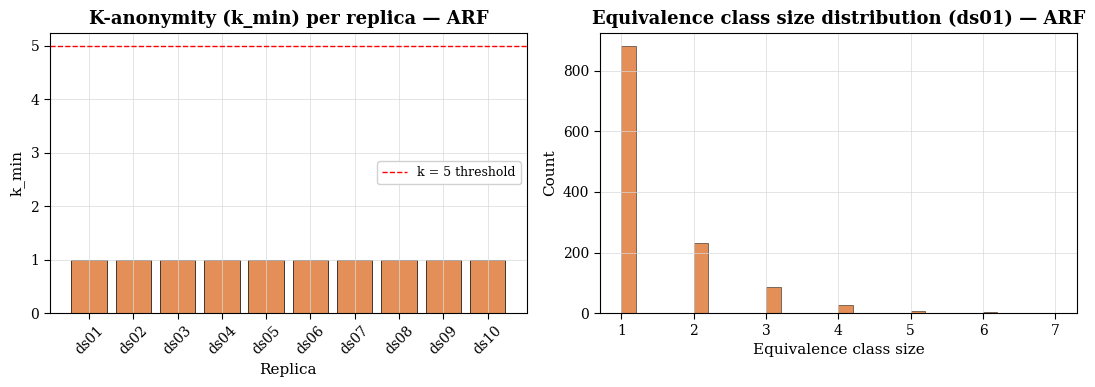

In [ ]:
# ── K-ANONYMITY ───────────────────────────────────────────────────────────────
# PURPOSE: Compute k-anonymity for each synthetic replica.
#
# CONCEPT: Group records by their quasi-identifier values; the minimum group
#          size is k_min. Continuous variables are discretised into deciles
#          for equivalence class computation (standard approach for mixed-type
#          data in tabular synthetic data evaluation).
#
# REFERENCE: Sweeney 2002; Qian et al. 2024 [N4A].
#
# INPUT:  replicas dict, AVAIL_QIDS list.
# OUTPUT: kanon_df (DataFrame), k_anonymity.csv, k_anonymity.png.


def compute_k_anonymity(df, quasi_ids, n_quantiles=10):
    """
    Compute k-anonymity for a single dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Synthetic dataset.
    quasi_ids : list[str]
        Quasi-identifier column names.
    n_quantiles : int
        Number of quantile bins for continuous variables.

    Returns
    -------
    k_min : int
        Minimum equivalence class size.
    group_sizes : pd.Series
        Size of each equivalence class.
    """
    df_qid = df[quasi_ids].copy()

    for col in quasi_ids:
        if df_qid[col].nunique() > n_quantiles:
            # Discretise continuous columns into quantile bins
            df_qid[col] = pd.qcut(
                df_qid[col].fillna(df_qid[col].median()),
                q=n_quantiles, labels=False, duplicates='drop'
            )
        else:
            # Already discrete (e.g. GCS categories) -> fill NaN with sentinel
            df_qid[col] = df_qid[col].fillna(-1).astype(int)

    group_sizes = df_qid.groupby(quasi_ids).size()
    return group_sizes.min(), group_sizes


# ── Compute per-replica ───────────────────────────────────────────────────────
kanon_results = {}
for key, df_s in replicas.items():
    k_min, sizes = compute_k_anonymity(df_s, AVAIL_QIDS)
    kanon_results[key] = {
        'k_min':    k_min,
        'mean':     sizes.mean(),
        'median':   sizes.median(),
        'n_groups': len(sizes),
    }
    status = 'OK' if k_min >= 5 else 'RISK'
    print(f"  {key}: k_min={k_min:>3d} | mean={sizes.mean():.1f} | "
          f"groups={len(sizes):>4d}  [{status}]")

kanon_df = pd.DataFrame(kanon_results).T
kanon_df.index.name = 'replica'
print(f"\nK-anonymity summary ({GENERATOR}):")
print(kanon_df.to_string())
kanon_df.to_csv(os.path.join(OUTPUT_DIR, 'k_anonymity.csv'))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Left: k_min per replica
k_mins = kanon_df['k_min'].astype(float)
axes[0].bar(kanon_df.index, k_mins, color=TFG_COLORS[GENERATOR],
            edgecolor='black', linewidth=0.6, alpha=0.85)
axes[0].axhline(5, color='red', linestyle='--', linewidth=1,
                label='k = 5 threshold')
axes[0].set_xlabel('Replica')
axes[0].set_ylabel('k_min')
axes[0].set_title(f'K-anonymity (k_min) per replica — {GENERATOR}')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# Right: equivalence class size distribution (first replica)
_, sizes_0 = compute_k_anonymity(replica_list[0], AVAIL_QIDS)
axes[1].hist(sizes_0.values, bins=30, color=TFG_COLORS[GENERATOR],
             edgecolor='black', linewidth=0.4, alpha=0.85)
axes[1].set_xlabel('Equivalence class size')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Equivalence class size distribution (ds01) — {GENERATOR}')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'k_anonymity.png'), dpi=150)
plt.show()

## **4. Nearest Neighbour Adversarial Accuracy (NNAA)**

NNAA [Vallevik et al. 2024, N3A; Alaa et al. (2022)] simulates a bidirectional
nearest-neighbour membership/overfitting attack.

### Bidirectional formulation

$$\text{NNAA} = \frac{1}{2}\,(\text{acc}_{s \to r} + \text{acc}_{r \to s})$$

where:

- $\text{acc}_{s \to r}$: proportion of synthetic records whose nearest **real**
  neighbour is closer than their nearest **other synthetic** neighbour.
- $\text{acc}_{r \to s}$: proportion of real records whose nearest **synthetic**
  neighbour is closer than their nearest **other real** neighbour.

### Interpretation

- **NNAA ≈ 0.5**: real and synthetic are well mixed in nearest-neighbour space.
- **NNAA > 0.60**: privacy/overfitting warning; synthetic records may be too
  close to real records.
- **NNAA < 0.40**: not a privacy failure, but a **fidelity/mixing warning**:
  synthetic and real records may be too separated.

### Inputs / outputs

- **Function:** `nnaa_attack(X_real, X_synth, subsample_n, random_state)`
  - Output: `(nnaa: float, acc_synth: float, acc_real: float)`.
- **Variables retained:** `nnaa_vals` (np.ndarray) — used by 9 Summary.
- **Exports:** `nnaa.csv`, `nnaa_barplot.png`.


  ds01: NNAA=0.4220  (s->r=0.556, r->s=0.288)  [OK]
  ds02: NNAA=0.4140  (s->r=0.524, r->s=0.304)  [OK]
  ds03: NNAA=0.4090  (s->r=0.540, r->s=0.278)  [OK]
  ds04: NNAA=0.4150  (s->r=0.542, r->s=0.288)  [OK]
  ds05: NNAA=0.4290  (s->r=0.542, r->s=0.316)  [OK]
  ds06: NNAA=0.4180  (s->r=0.558, r->s=0.278)  [OK]
  ds07: NNAA=0.4090  (s->r=0.518, r->s=0.300)  [OK]
  ds08: NNAA=0.4110  (s->r=0.536, r->s=0.286)  [OK]
  ds09: NNAA=0.4070  (s->r=0.508, r->s=0.306)  [OK]
  ds10: NNAA=0.4070  (s->r=0.526, r->s=0.288)  [OK]

NNAA mean +/- SD : 0.4141 +/- 0.0068
NNAA range       : [0.4070, 0.4290]
(Ideal ≈ 0.5; fidelity warning < 0.4; privacy risk > 0.6)


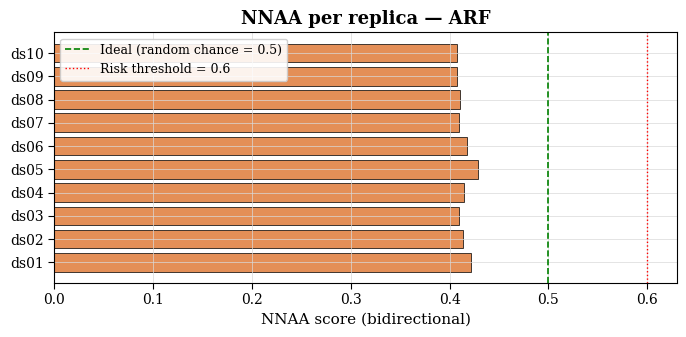

In [ ]:
# ── NNAA — NEAREST NEIGHBOUR ADVERSARIAL ACCURACY ────────────────────────────
# PURPOSE: Simulate a bidirectional nearest-neighbour membership inference attack.
#
# Methodological correction: NNAA is computed bidirectionally rather than only
# in the synth->real direction. The full NNAA metric is:
#   NNAA = 0.5 * (acc_synth + acc_real)
# where:
#   - acc_synth: proportion of synthetic records whose nearest real neighbour
#     is closer than their nearest other synthetic neighbour.
#   - acc_real: proportion of real records whose nearest synthetic neighbour
#     is closer than their nearest other real neighbour.
#
# SUBSAMPLING: n = SUBSAMPLE_N balanced samples from both sets.
#
# REFERENCE: Vallevik et al. 2024 [N3A]; Alaa et al. (2022).


def nnaa_attack(X_real, X_synth, subsample_n=SUBSAMPLE_N, random_state=42):
    """Compute the bidirectional Nearest-Neighbour Adversarial Accuracy.

    Parameters
    ----------
    X_real : np.ndarray
        Scaled real training data (rows = records, cols = features).
    X_synth : np.ndarray
        Scaled synthetic data with the same number of columns as ``X_real``.
    subsample_n : int, default ``SUBSAMPLE_N``
        Balanced sample size used in both attack directions. Sampling is done
        with replacement only when the source set has fewer than ``n`` records.
    random_state : int, default 42
        Seed for the balanced subsampling step.

    Returns
    -------
    nnaa : float
        Bidirectional NNAA. ``0.5`` is the ideal (real and synthetic well
        mixed); ``1.0`` is the worst (perfect attacker discrimination).
    acc_synth : float
        Synth-to-Real attack accuracy: proportion of synthetic records whose
        nearest real neighbour is closer than their nearest other synthetic
        neighbour.
    acc_real : float
        Real-to-Synth attack accuracy: proportion of real records whose
        nearest synthetic neighbour is closer than their nearest other real
        neighbour.
    """
    rng = np.random.RandomState(random_state)
    n   = min(subsample_n, len(X_real), len(X_synth))

    # Balanced subsampling (with replacement if cohort < n)
    idx_r = rng.choice(len(X_real),  n, replace=(len(X_real)  < n))
    idx_s = rng.choice(len(X_synth), n, replace=(len(X_synth) < n))

    Xr = X_real[idx_r]
    Xs = X_synth[idx_s]

    tree_real  = BallTree(Xr, metric='euclidean')
    tree_synth = BallTree(Xs, metric='euclidean')

    # -- Direction 1: Synth -> Real --
    # For each synthetic record: is the nearest real neighbour closer
    # than the nearest OTHER synthetic neighbour?
    correct_synth = 0
    for i in range(n):
        s_i = Xs[i:i+1]
        d_real, _  = tree_real.query(s_i, k=1)
        d_synth, _ = tree_synth.query(s_i, k=2)       # k=2: exclude self
        if d_real[0, 0] < d_synth[0, 1]:
            correct_synth += 1

    # -- Direction 2: Real -> Synth --
    # For each real record: is the nearest synthetic neighbour closer
    # than the nearest OTHER real neighbour?
    correct_real = 0
    for i in range(n):
        r_i = Xr[i:i+1]
        d_synth, _ = tree_synth.query(r_i, k=1)
        d_real, _  = tree_real.query(r_i, k=2)         # k=2: exclude self
        if d_synth[0, 0] < d_real[0, 1]:
            correct_real += 1

    acc_synth = correct_synth / n
    acc_real  = correct_real / n
    nnaa      = 0.5 * (acc_synth + acc_real)

    return nnaa, acc_synth, acc_real


# ── Compute per-replica ───────────────────────────────────────────────────────
nnaa_records = []
for key, df_s in replicas.items():
    X_s = scaler.transform(imp.transform(df_s[AVAIL_FEATURES]))
    nnaa_val, acc_s, acc_r = nnaa_attack(X_real, X_s)
    status = ('PRIVACY_RISK' if nnaa_val > NNAA_RISK_THR else
              'FIDELITY_WARNING' if nnaa_val < NNAA_LOW_THR else 'OK')
    print(f"  {key}: NNAA={nnaa_val:.4f}  "
          f"(s->r={acc_s:.3f}, r->s={acc_r:.3f})  [{status}]")
    nnaa_records.append({
        'replica':   key,
        'NNAA':      nnaa_val,
        'acc_synth': acc_s,
        'acc_real':  acc_r,
    })

nnaa_df   = pd.DataFrame(nnaa_records)
nnaa_vals = nnaa_df['NNAA'].values

print(f"\nNNAA mean +/- SD : {nnaa_vals.mean():.4f} +/- {nnaa_vals.std():.4f}")
print(f"NNAA range       : [{nnaa_vals.min():.4f}, {nnaa_vals.max():.4f}]")
print(f"(Ideal ≈ 0.5; fidelity warning < {NNAA_LOW_THR}; privacy risk > {NNAA_RISK_THR})")

nnaa_df.to_csv(os.path.join(OUTPUT_DIR, 'nnaa.csv'), index=False)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(nnaa_df['replica'], nnaa_vals,
        color=TFG_COLORS[GENERATOR], edgecolor='black',
        linewidth=0.6, alpha=0.85)
ax.axvline(0.5, color='green', linestyle='--', linewidth=1.2,
           label='Ideal (random chance = 0.5)')
ax.axvline(NNAA_RISK_THR, color='red', linestyle=':', linewidth=1.0,
           label=f'Risk threshold = {NNAA_RISK_THR}')
ax.set_xlabel('NNAA score (bidirectional)')
ax.set_title(f'NNAA per replica — {GENERATOR}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'nnaa_barplot.png'), dpi=150)
plt.show()

## **5. Nearest Neighbour Distances (NND) and Near-Copy Detection (NNDR)**

### NND (Nearest Neighbour Distance)

For each synthetic record, the Euclidean distance to its nearest real training
record is computed. A healthy synthetic dataset should have a NND distribution
**similar** to the real intra-set distance distribution (real-to-real NND),
indicating that synthetic records are no closer to real records than real
records are to each other.

### NNDR (Nearest Neighbour Distance Ratio)

The ratio between the first and second nearest-neighbour distances from each
synthetic record to the real data:

$$\text{NNDR}_i = \frac{d_1(\text{synth}_i, \text{real})}{d_2(\text{synth}_i, \text{real})}$$

A low NNDR (close to 0) signals that one real record is disproportionately
closer than all others — a signature of near-copying or overfitting.

**Threshold for concern:** NNDR < `NNDR_THRESHOLD` (default 0.5) flags
potential near-copies [Vallevik et al. 2024, N3A].

### Inputs / outputs

- **Input:** `X_real`, `X_synth_all`, per-replica `X_s` (all scaled).
- **Variables retained (required by 8 Authenticity):**
  - `tree_real_full` — BallTree on all real training records (unsubsampled).
  - `nnd_real_ref` — real-to-real NND values (intra-set reference).
  - `nnd_all_synth`, `nndr_all_synth` — pooled synth-to-real NND and NNDR.
- **Exports:** `nnd_nndr.csv`, `nnd_nndr.png`.

### Reporting note

If any replica produces exact zero distances or an unusually high near-copy
rate, report it explicitly rather than excluding it automatically. Such a result
is a potential generator/run failure and should be investigated before drawing
aggregate conclusions.


  ds01: NND mean=1.7063 | NNDR mean=0.9204 | near-copy rate=0.0020
  ds02: NND mean=1.7335 | NNDR mean=0.9269 | near-copy rate=0.0000
  ds03: NND mean=1.7226 | NNDR mean=0.9251 | near-copy rate=0.0000
  ds04: NND mean=1.7112 | NNDR mean=0.9241 | near-copy rate=0.0000
  ds05: NND mean=1.7556 | NNDR mean=0.9235 | near-copy rate=0.0000
  ds06: NND mean=1.7461 | NNDR mean=0.9199 | near-copy rate=0.0000
  ds07: NND mean=1.7080 | NNDR mean=0.9252 | near-copy rate=0.0000
  ds08: NND mean=1.7217 | NNDR mean=0.9188 | near-copy rate=0.0000
  ds09: NND mean=1.7064 | NNDR mean=0.9253 | near-copy rate=0.0020
  ds10: NND mean=1.6980 | NNDR mean=0.9251 | near-copy rate=0.0000

Pooled NND   — synth->real: 1.7209 | real->real ref: 1.2292
Pooled NNDR  — mean: 0.9234 | near-copy rate (NNDR < 0.5): 0.0004


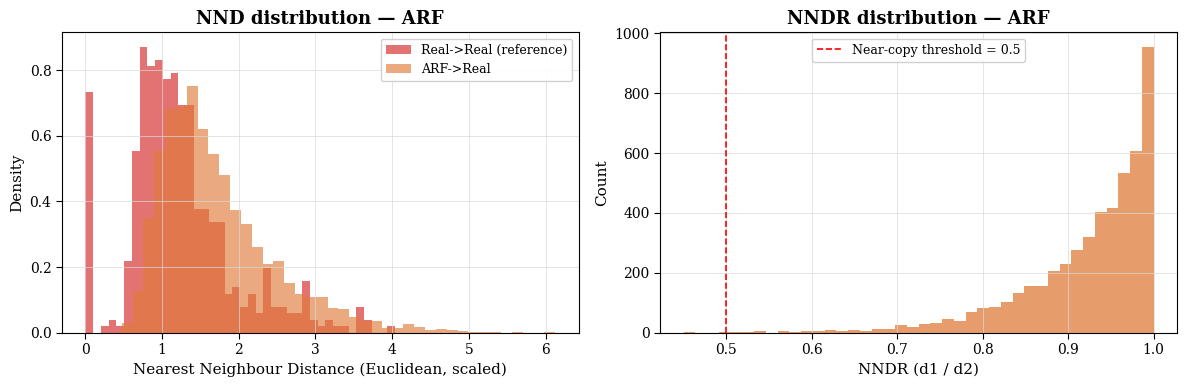

In [ ]:
# ── NND AND NNDR ──────────────────────────────────────────────────────────────
# PURPOSE:
#   (a) Compute NND distribution: synth->real vs. real->real (intra-set ref).
#   (b) Compute NNDR per synthetic record; flag near-copies (NNDR < 0.5).
#
# NOTE: tree_real_full is built here on the FULL real set and reused in the
#       Authenticity cell. Both cells must be executed in order.
#
# SUBSAMPLING: SUBSAMPLE_N per group for the distributions.
#              tree_real_full uses the full real set for query accuracy.
#
# REFERENCE: Vallevik et al. 2024 [N3A]; Alaa et al. (2022).


def subsample(X, n, seed=42):
    """Return a balanced subsample of ``X`` of size ``min(len(X), n)``.

    Sampling is done without replacement when ``len(X) >= n`` and with
    replacement otherwise. This matches the NB8 subsampling convention so that
    NND, NNDR, NNAA and authenticity all operate on comparable sample sizes.

    Parameters
    ----------
    X : np.ndarray
        Scaled feature matrix, shape (n_records, n_features).
    n : int
        Target subsample size.
    seed : int, default 42
        Reproducibility seed.

    Returns
    -------
    np.ndarray
        Subsampled feature matrix.
    """
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(X), min(n, len(X)), replace=(len(X) < n))
    return X[idx]


# ── Build BallTree on full real set (reused in Authenticity cell) ─────────────
tree_real_full = BallTree(X_real, metric='euclidean')

# ── Intra-real NND reference distribution ─────────────────────────────────────
# Query with subsample; k=2 because first NN of a real record in its own
# tree is itself (distance 0) -> take index 1 as the nearest OTHER real record.
Xr_sub = subsample(X_real, SUBSAMPLE_N)
nnd_real_to_real, _ = tree_real_full.query(Xr_sub, k=2)
nnd_real_ref = nnd_real_to_real[:, 1]

# ── Per-replica NND and NNDR ──────────────────────────────────────────────────
nnd_synth_records  = {}
nndr_synth_records = {}

for key, df_s in replicas.items():
    X_s     = scaler.transform(imp.transform(df_s[AVAIL_FEATURES]))
    X_s_sub = subsample(X_s, SUBSAMPLE_N)

    # Synthetic -> Real: k=2 to get both d1 and d2 for NNDR
    dists, _ = tree_real_full.query(X_s_sub, k=2)
    nnd_s  = dists[:, 0]                                 # first real NN
    nndr_s = dists[:, 0] / (dists[:, 1] + 1e-12)         # d1 / d2

    nnd_synth_records[key]  = nnd_s
    nndr_synth_records[key] = nndr_s

    near_copy_rate = (nndr_s < NNDR_THRESHOLD).mean()
    print(f"  {key}: NND mean={nnd_s.mean():.4f} | "
          f"NNDR mean={nndr_s.mean():.4f} | "
          f"near-copy rate={near_copy_rate:.4f}")

# ── Aggregate across replicas ─────────────────────────────────────────────────
nnd_all_synth  = np.concatenate(list(nnd_synth_records.values()))
nndr_all_synth = np.concatenate(list(nndr_synth_records.values()))

print(f"\nPooled NND   — synth->real: {nnd_all_synth.mean():.4f} | "
      f"real->real ref: {nnd_real_ref.mean():.4f}")
print(f"Pooled NNDR  — mean: {nndr_all_synth.mean():.4f} | "
      f"near-copy rate (NNDR < {NNDR_THRESHOLD}): "
      f"{(nndr_all_synth < NNDR_THRESHOLD).mean():.4f}")

# ── Summary per replica ───────────────────────────────────────────────────────
nnd_summary = pd.DataFrame({
    'replica':        list(nnd_synth_records.keys()),
    'NND_mean':       [v.mean() for v in nnd_synth_records.values()],
    'NND_std':        [v.std()  for v in nnd_synth_records.values()],
    'NNDR_mean':      [v.mean() for v in nndr_synth_records.values()],
    'near_copy_rate': [(v < NNDR_THRESHOLD).mean()
                       for v in nndr_synth_records.values()],
})
nnd_summary.to_csv(os.path.join(OUTPUT_DIR, 'nnd_nndr.csv'), index=False)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: NND distribution comparison
axes[0].hist(nnd_real_ref, bins=40, alpha=0.55, color=TFG_COLORS['real'],
             label='Real->Real (reference)', density=True, edgecolor='none')
axes[0].hist(nnd_all_synth, bins=40, alpha=0.65, color=TFG_COLORS[GENERATOR],
             label=f'{GENERATOR}->Real', density=True, edgecolor='none')
axes[0].set_xlabel('Nearest Neighbour Distance (Euclidean, scaled)')
axes[0].set_ylabel('Density')
axes[0].set_title(f'NND distribution — {GENERATOR}')
axes[0].legend()

# Right: NNDR distribution
axes[1].hist(nndr_all_synth, bins=40, alpha=0.75,
             color=TFG_COLORS[GENERATOR], edgecolor='none')
axes[1].axvline(NNDR_THRESHOLD, color='red', linestyle='--', linewidth=1.2,
               label=f'Near-copy threshold = {NNDR_THRESHOLD}')
axes[1].set_xlabel('NNDR (d1 / d2)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'NNDR distribution — {GENERATOR}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'nnd_nndr_plots.png'), dpi=150)
plt.show()

## **6. Membership Disclosure — El Emam corrected F1**

The **membership disclosure** metric evaluates whether an adversary can infer
that a target individual was included in the real training data used to train
the generator.

This section implements the El Emam partitioning method, not a generic
real-vs-synthetic classifier.

### Correct attack-set prevalence

The attack dataset must contain members in the same expected proportion as an
attacker sampling targets from the source population:

$$t = \frac{n_{\text{train}}}{N_{\text{population}}}$$

Using a 50/50 member/non-member attack dataset is incorrect unless the real
training data cover 50% of the population.

### Matching rule

1. Continuous features are discretised into quantile bins fitted on the real
   training reference.
2. Each attack record is matched to the nearest synthetic record using Hamming
   distance over the binned features.
3. A record is predicted as "member" if its minimum Hamming mismatch count is
   ≤ `MD_HAMMING_THRESHOLD`.

For this dataset, `MD_HAMMING_THRESHOLD = 1` is deliberately strict: with 12
available features, a match may differ in at most one binned feature. A
sensitivity analysis with 0, 1 and 2 mismatches can be added if required.

### Corrected relative F1

The naive attacker predicts every target as a member:

$$F1_{\text{naive}} = \frac{2t}{1+t}$$

The corrected relative score is:

$$F_{\text{rel}} =
\frac{F1_{\text{attack}} - F1_{\text{naive}}}
     {1 - F1_{\text{naive}}}$$

**Threshold:** `F_rel ≤ 0.20` is considered acceptable in the El Emam framework.

Negative `F_rel` values indicate that the attack performs below the naive
baseline. They are not interpreted as additional privacy protection, but simply
as **no measurable membership advantage**.

### Inputs / outputs

- **Function:** `membership_disclosure_partitioning(...)`
- **Variables retained:** `f1_att_pool`, `f1_nai_pool`, `f1_rel_pool`
- **Exports:** `membership_disclosure.csv`, `membership_disclosure.png`


Population size      : 1,364,952
Real train size      : 1781
Real holdout size    : 595
t = n_train / N      : 0.001305
F1_naive             : 0.002606
Hamming match rule   : <= 1 mismatched binned feature(s)
Attack size target   : max(20000, ceil(25/t))

  ds01: F1=0.0000 | F1_naive=0.002606 | F_rel=-0.0026 | precision=0.000 | recall=0.000  [PASS]
  ds02: F1=0.0000 | F1_naive=0.002606 | F_rel=-0.0026 | precision=0.000 | recall=0.000  [PASS]
  ds03: F1=0.0000 | F1_naive=0.002606 | F_rel=-0.0026 | precision=0.000 | recall=0.000  [PASS]
  ds04: F1=0.0000 | F1_naive=0.002606 | F_rel=-0.0026 | precision=0.000 | recall=0.000  [PASS]
  ds05: F1=0.0000 | F1_naive=0.002606 | F_rel=-0.0026 | precision=0.000 | recall=0.000  [PASS]
  ds06: F1=0.0000 | F1_naive=0.002606 | F_rel=-0.0026 | precision=0.000 | recall=0.000  [PASS]
  ds07: F1=0.0000 | F1_naive=0.002606 | F_rel=-0.0026 | precision=0.000 | recall=0.000  [PASS]
  ds08: F1=0.0000 | F1_naive=0.002606 | F_rel=-0.0026 | precision=0.000 | recal

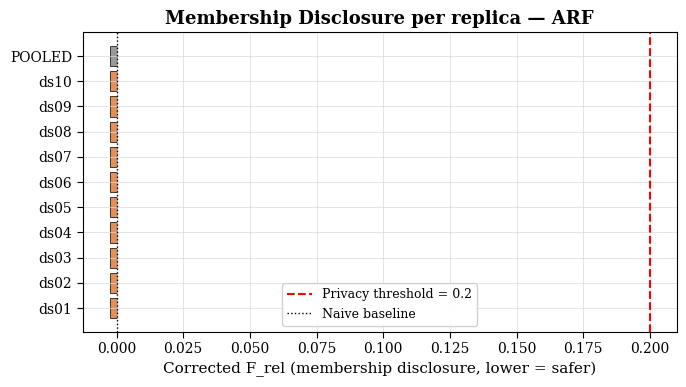

In [ ]:
# ── MEMBERSHIP DISCLOSURE — EL EMAM PARTITIONING METHOD ──────────────────────
# PURPOSE: Compute the corrected El Emam membership disclosure metric.
#
# This replaces the earlier real-vs-synthetic Random Forest distinguishability
# classifier. The El Emam metric is a membership attack based on:
#   1. an attack dataset containing members + non-members,
#   2. the correct member fraction t = n_train / population_size,
#   3. nearest matching between attack records and the released synthetic data,
#   4. F1 for predicted membership,
#   5. corrected relative F1:
#        F_rel = (F1_attack - F1_naive) / (1 - F1_naive)
#
# REFERENCE: El Emam, Mosquera & Fang (JAMIA Open 2022); used in N1E.

assert 'df_holdout' in globals(), "df_holdout not found. Run 1 Data Loading first."


def _numeric_bin_edges(series, n_bins=10):
    """Build robust quantile bin edges from a numeric reference series.

    Edges are derived from ``n_bins`` quantiles of the real training data and
    de-duplicated. If too few unique quantiles survive (heavily discrete or
    constant variable), the function falls back to midpoint edges between the
    observed unique values. The first and last edges are forced to ``-inf``
    and ``+inf`` so that records outside the observed range are still binned.

    Parameters
    ----------
    series : pd.Series
        Real-reference values for the variable.
    n_bins : int, default 10
        Number of quantile bins to attempt.

    Returns
    -------
    np.ndarray
        Strictly increasing array of bin edges suitable for ``pd.cut``.
    """
    s = pd.to_numeric(series, errors='coerce').dropna()
    if s.empty:
        return np.array([-np.inf, np.inf])

    qs = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(np.nanquantile(s, qs))

    # If the variable has too few unique quantiles, fall back to unique values.
    if len(edges) <= 2:
        vals = np.unique(s)
        if len(vals) <= 1:
            v = vals[0] if len(vals) else 0.0
            edges = np.array([v - 1e-9, v + 1e-9])
        else:
            mids = (vals[:-1] + vals[1:]) / 2.0
            edges = np.concatenate([[vals[0] - 1e-9], mids, [vals[-1] + 1e-9]])

    edges[0]  = -np.inf
    edges[-1] =  np.inf
    return edges


def fit_hamming_binner(df_reference, features, n_bins=10):
    """Fit per-feature binning/encoding rules from the real reference.

    Numeric columns are turned into integer-coded quantile bins via
    ``_numeric_bin_edges``; non-numeric columns are mapped to integer codes
    using their ordered categorical values. The rules are then applied to any
    DataFrame via ``transform_hamming`` for the El Emam Hamming-matching
    attack.

    Parameters
    ----------
    df_reference : pd.DataFrame
        Real training reference; the binning is fitted on its columns.
    features : list of str
        Columns to include in the matching.
    n_bins : int, default 10
        Number of quantile bins for numeric columns.

    Returns
    -------
    dict
        Mapping ``column -> {'type': 'numeric'|'categorical', ...}`` consumed
        by ``transform_hamming``.
    """
    spec = {}
    for col in features:
        if pd.api.types.is_numeric_dtype(df_reference[col]):
            spec[col] = {
                'type': 'numeric',
                'edges': _numeric_bin_edges(df_reference[col], n_bins=n_bins),
            }
        else:
            cats = pd.Series(df_reference[col].astype('category').cat.categories)
            mapping = {v: i for i, v in enumerate(cats)}
            spec[col] = {'type': 'categorical', 'mapping': mapping}
    return spec


def transform_hamming(df, spec, features):
    """Apply a fitted Hamming binner to a DataFrame.

    Numeric columns are binned with the precomputed edges from ``spec``; non-
    numeric columns are mapped to integer codes from the precomputed
    dictionary. Missing values and unseen categories are coded as ``-1`` so
    that they cannot match any reference record by accident.

    Parameters
    ----------
    df : pd.DataFrame
        Records to encode (real members, real non-members or synthetic).
    spec : dict
        Output of ``fit_hamming_binner``.
    features : list of str
        Columns to encode, in the desired output order.

    Returns
    -------
    np.ndarray
        Integer-coded matrix of shape ``(len(df), len(features))`` suitable
        for Hamming-distance nearest-neighbour search.
    """
    cols = []
    for col in features:
        if spec[col]['type'] == 'numeric':
            vals = pd.to_numeric(df[col], errors='coerce')
            codes = pd.cut(
                vals,
                bins=spec[col]['edges'],
                labels=False,
                include_lowest=True,
                duplicates='drop'
            )
            codes = pd.Series(codes, index=df.index).fillna(-1).astype(int).to_numpy()
        else:
            mapping = spec[col]['mapping']
            codes = df[col].map(mapping).fillna(-1).astype(int).to_numpy()
        cols.append(codes)
    return np.vstack(cols).T.astype(np.int16)


def make_attack_dataset_codes(real_codes, holdout_codes, t, attack_size,
                              min_positives=25, random_state=42):
    """Build an attack dataset with the El Emam-correct member fraction.

    The attacker's prior probability of selecting a training member is
    ``t = n_train / population_size``, which is typically very small in
    hospital cohorts. To avoid a nearly empty positive class, ``attack_size``
    is increased until at least ``min_positives`` members are expected in
    expectation. Sampling is with replacement, matching the paper's idea of
    drawing target individuals from the underlying population.

    Parameters
    ----------
    real_codes : np.ndarray
        Hamming-encoded real training records (members).
    holdout_codes : np.ndarray
        Hamming-encoded real held-out records (non-members).
    t : float
        Population member fraction ``n_train / population_size``.
    attack_size : int
        Base attack-set size; increased if needed to satisfy
        ``min_positives``.
    min_positives : int, default 25
        Minimum expected number of members in the attack set.
    random_state : int, default 42
        Reproducibility seed.

    Returns
    -------
    X_attack : np.ndarray
        Attack record codes (members + non-members, shuffled).
    y_attack : np.ndarray
        Binary labels (1 = member, 0 = non-member).
    attack_size_eff : int
        Effective attack-set size used.
    n_members : int
        Number of member records in the attack set.
    """
    rng = np.random.RandomState(random_state)
    attack_size_eff = int(max(attack_size, np.ceil(min_positives / max(t, 1e-12))))

    n_members = max(1, int(round(attack_size_eff * t)))
    n_members = min(n_members, attack_size_eff - 1)
    n_nonmembers = attack_size_eff - n_members

    idx_m = rng.choice(len(real_codes),    size=n_members,    replace=True)
    idx_h = rng.choice(len(holdout_codes), size=n_nonmembers, replace=True)

    X_attack = np.vstack([real_codes[idx_m], holdout_codes[idx_h]])
    y_attack = np.array([1] * n_members + [0] * n_nonmembers)

    perm = rng.permutation(len(y_attack))
    return X_attack[perm], y_attack[perm], attack_size_eff, n_members


def membership_disclosure_partitioning(df_train, df_holdout, df_synth,
                                       features,
                                       population_size=POPULATION_SIZE,
                                       n_bins=MD_N_BINS,
                                       hamming_threshold=MD_HAMMING_THRESHOLD,
                                       attack_size=MD_ATTACK_SIZE,
                                       min_positives=MD_MIN_POSITIVES,
                                       random_state=42):
    """Compute the corrected El Emam membership disclosure metric.

    The attacker holds the synthetic dataset and is given an attack set
    containing real members and non-members in the same proportion
    ``t = n_train / population_size`` an attacker would face if sampling
    targets at random from the source population. Each attack record is
    predicted as a member when its nearest synthetic record (under Hamming
    distance on binned features) differs in no more than
    ``hamming_threshold`` features.

    Parameters
    ----------
    df_train : pd.DataFrame
        Real training records (members).
    df_holdout : pd.DataFrame
        Real held-out records (non-members).
    df_synth : pd.DataFrame
        Released synthetic dataset (one replica, or all replicas pooled).
    features : list of str
        Columns used for matching.
    population_size : int, default ``POPULATION_SIZE``
        Naive-attacker population size used to compute ``t``.
    n_bins : int, default ``MD_N_BINS``
        Number of quantile bins for numeric features.
    hamming_threshold : int, default ``MD_HAMMING_THRESHOLD``
        Maximum number of mismatched binned features tolerated for a match.
    attack_size : int, default ``MD_ATTACK_SIZE``
        Target attack-set size.
    min_positives : int, default ``MD_MIN_POSITIVES``
        Minimum expected number of members in the attack set.
    random_state : int, default 42
        Reproducibility seed.

    Returns
    -------
    dict
        Keys: ``F1_attack`` (attacker F1), ``precision``, ``recall``,
        ``F1_naive`` (naive baseline ``2t / (1 + t)``),
        ``F_rel`` (corrected relative F1, lower = safer),
        ``t_member_fraction``, ``attack_size`` (effective size used),
        ``n_members_attack``, ``n_predicted_members``,
        ``hamming_threshold``, ``n_bins``.
    """
    if len(df_holdout) == 0:
        raise ValueError('df_holdout is empty; membership disclosure needs non-members.')

    binner = fit_hamming_binner(df_train, features, n_bins=n_bins)
    train_codes   = transform_hamming(df_train[features],   binner, features)
    holdout_codes = transform_hamming(df_holdout[features], binner, features)
    synth_codes   = transform_hamming(df_synth[features],   binner, features)

    t = len(df_train) / population_size

    X_attack, y_attack, attack_size_eff, n_members = make_attack_dataset_codes(
        train_codes, holdout_codes, t=t,
        attack_size=attack_size, min_positives=min_positives,
        random_state=random_state
    )

    # Hamming distance from each attack record to nearest synthetic record.
    # sklearn returns the fraction of mismatched features, hence multiply by d.
    nn = NearestNeighbors(metric='hamming', algorithm='brute', n_jobs=-1)
    nn.fit(synth_codes)
    dist_frac, _ = nn.kneighbors(X_attack, n_neighbors=1, return_distance=True)

    d = len(features)
    min_mismatches = dist_frac[:, 0] * d
    y_pred = (min_mismatches <= hamming_threshold + 1e-12).astype(int)

    precision = precision_score(y_attack, y_pred, zero_division=0)
    recall    = recall_score(y_attack, y_pred, zero_division=0)
    f1_att    = f1_score(y_attack, y_pred, zero_division=0)

    # Naive attacker: classify all targets as members.
    # precision = t; recall = 1; F1 = 2t/(1+t).
    f1_naive = 2.0 * t / (1.0 + t)

    # Corrected relative F1 from El Emam et al.; analogous to a relative
    # improvement over the naive baseline. Negative values mean worse than naive.
    f_rel = (f1_att - f1_naive) / (1.0 - f1_naive + 1e-12)

    return {
        'F1_attack': f1_att,
        'precision': precision,
        'recall': recall,
        'F1_naive': f1_naive,
        'F_rel': f_rel,
        't_member_fraction': t,
        'attack_size': attack_size_eff,
        'n_members_attack': n_members,
        'n_predicted_members': int(y_pred.sum()),
        'hamming_threshold': hamming_threshold,
        'n_bins': n_bins,
    }


# ── Per-replica evaluation ────────────────────────────────────────────────────
print(f"Population size      : {POPULATION_SIZE:,}")
print(f"Real train size      : {len(df_real)}")
print(f"Real holdout size    : {len(df_holdout)}")
print(f"t = n_train / N      : {len(df_real)/POPULATION_SIZE:.6f}")
print(f"F1_naive             : {2*(len(df_real)/POPULATION_SIZE)/(1 + len(df_real)/POPULATION_SIZE):.6f}")
print(f"Hamming match rule   : <= {MD_HAMMING_THRESHOLD} mismatched binned feature(s)")
print(f"Attack size target   : max({MD_ATTACK_SIZE}, ceil({MD_MIN_POSITIVES}/t))")
print()

md_records = []
for j, (key, df_s) in enumerate(replicas.items(), start=1):
    res = membership_disclosure_partitioning(
        df_real, df_holdout, df_s, AVAIL_FEATURES,
        population_size=POPULATION_SIZE,
        random_state=42 + j
    )
    status = 'PASS' if res['F_rel'] <= MD_THRESHOLD else 'FAIL'
    print(f"  {key}: F1={res['F1_attack']:.4f} | "
          f"F1_naive={res['F1_naive']:.6f} | "
          f"F_rel={res['F_rel']:.4f} | "
          f"precision={res['precision']:.3f} | recall={res['recall']:.3f}  [{status}]")
    md_records.append({'replica': key, **res})

# ── Pooled evaluation (El Emam/N1E: evaluate pooled synthetic release) ────────
df_synth_pooled = pd.concat(replicas.values(), ignore_index=True)
res_pool = membership_disclosure_partitioning(
    df_real, df_holdout, df_synth_pooled, AVAIL_FEATURES,
    population_size=POPULATION_SIZE,
    random_state=999
)
f1_att_pool = res_pool['F1_attack']
f1_nai_pool = res_pool['F1_naive']
f1_rel_pool = res_pool['F_rel']

status_pool = 'PASS' if f1_rel_pool <= MD_THRESHOLD else 'FAIL'
print(f"\nPooled (all replicas): F1={f1_att_pool:.4f} | "
      f"F1_naive={f1_nai_pool:.6f} | F_rel={f1_rel_pool:.4f}  [{status_pool}]")
print(f"(Corrected threshold: F_rel <= {MD_THRESHOLD})")

# ── Save ──────────────────────────────────────────────────────────────────────
md_df = pd.DataFrame(md_records)
md_df.loc[len(md_df)] = {'replica': 'POOLED', **res_pool}
md_df.to_csv(os.path.join(OUTPUT_DIR, 'membership_disclosure.csv'), index=False)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bar_colors = [TFG_COLORS[GENERATOR] if r != 'POOLED' else TFG_COLORS['neutral']
              for r in md_df['replica']]
ax.barh(md_df['replica'], md_df['F_rel'],
        color=bar_colors, edgecolor='black', linewidth=0.6, alpha=0.85)
ax.axvline(MD_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
           label=f'Privacy threshold = {MD_THRESHOLD}')
ax.axvline(0.0, color='black', linestyle=':', linewidth=1.0,
           label='Naive baseline')
ax.set_xlabel('Corrected F_rel (membership disclosure, lower = safer)')
ax.set_title(f'Membership Disclosure per replica — {GENERATOR}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'membership_disclosure.png'), dpi=150)
plt.show()


## **7. Linkability**

**Linkability** evaluates whether synthetic records can be used to uniquely
identify real training individuals through their quasi-identifier combinations.
The approach adapts the NNDR concept (reviewed in Hernandez et al. 2022)
to the QID-only feature subspace.

### Formulation

For each synthetic record *s*, the two nearest real records *r₁* and *r₂* in
**QID space** are found. The QID-NNDR is:

$$\text{QID-NNDR}_i = \frac{d(s_i,\ r_1)}{d(s_i,\ r_2)}$$

A synthetic record is considered a **unique link** to *r₁* if
QID-NNDR < `LINK_THRESHOLD` (default 0.5): one real record is
disproportionately close compared to all others.

**Linkability rate** = proportion of synthetic records that uniquely link to
a real training record.

### Interpretation

- **< 5 %**: acceptable linkability risk.
- **5–10 %**: elevated warning; investigate QID distribution overlap.
- **> 10 %**: high risk; synthetic QID combinations are too close to training data.

### Relation to other metrics

| Metric | Direction | Feature space |
|--------|-----------|---------------|
| K-anonymity | Synthetic equivalence classes | QID (discretised) |
| NND / NNDR | Synthetic → Real | All features |
| **Linkability** | Synthetic → Real (unique link) | QID only (continuous) |

Linkability is more targeted than full-feature NNDR: it uses only the
quasi-identifiers that an external attacker could plausibly cross-reference
(age, key vital signs), ignoring clinically sensitive but non-identifiable
variables (Lactato, TT).

### Inputs / outputs

- **Function:** `compute_linkability(X_synth_full, qid_idx, tree_real_qid, ...)`
  - Input: scaled synthetic matrix (all features), QID column indices,
    BallTree over real QID features.
  - Output: `(link_rate: float, n_linked: int, nndr_qid: np.ndarray)`.
- **Variables retained:** `link_df` (DataFrame) — used by 9 Summary.
- **Exports:** `linkability.csv`, `linkability_barplot.png`.


  ds01: link_rate=9.60%  n_linked=  48  NNDR_QID_mean=0.797  [WARN]
  ds02: link_rate=6.20%  n_linked=  31  NNDR_QID_mean=0.816  [WARN]
  ds03: link_rate=10.00%  n_linked=  50  NNDR_QID_mean=0.794  [RISK]
  ds04: link_rate=7.60%  n_linked=  38  NNDR_QID_mean=0.802  [WARN]
  ds05: link_rate=9.80%  n_linked=  49  NNDR_QID_mean=0.779  [WARN]
  ds06: link_rate=10.40%  n_linked=  52  NNDR_QID_mean=0.797  [RISK]
  ds07: link_rate=8.20%  n_linked=  41  NNDR_QID_mean=0.805  [WARN]
  ds08: link_rate=10.00%  n_linked=  50  NNDR_QID_mean=0.784  [RISK]
  ds09: link_rate=9.40%  n_linked=  47  NNDR_QID_mean=0.798  [WARN]
  ds10: link_rate=9.80%  n_linked=  49  NNDR_QID_mean=0.801  [WARN]

Mean linkability rate : 9.10%
Max  linkability rate : 10.40%
(Threshold: QID-NNDR < 0.5; warn > 5%, risk > 10%)


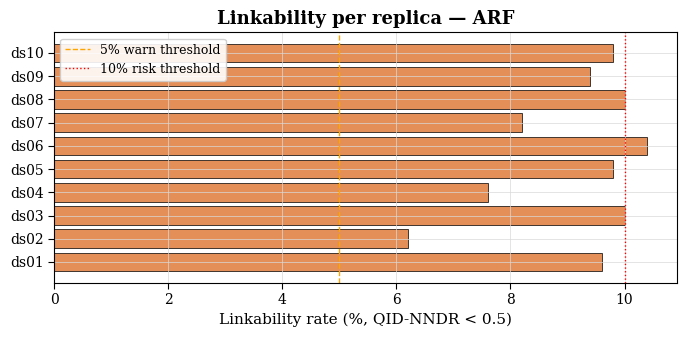

In [ ]:
# ── LINKABILITY ───────────────────────────────────────────────────────────────
# PURPOSE: Assess whether synthetic records can be uniquely linked to real
#          training records via quasi-identifier (QID) similarity.
#
# CONCEPT: NNDR applied in the QID-only feature subspace. A synthetic record
#          with QID-NNDR < 0.5 has one real record disproportionately closer
#          than all others in QID space — a "unique link" an attacker could
#          exploit using demographic/physiological auxiliary data.
#
# REFERENCE: Hernandez et al. 2022 [N3D] — linkability framework for synthetic
#            tabular health records.
#
# INPUT:  replicas dict, X_real (all features, scaled), AVAIL_FEATURES,
#         AVAIL_QIDS, LINK_THRESHOLD, SUBSAMPLE_N.
# OUTPUT: link_df (DataFrame), linkability.csv, linkability_barplot.png.

# ── QID index slices in the scaled feature matrix ─────────────────────────────
qid_idx = [AVAIL_FEATURES.index(q) for q in AVAIL_QIDS if q in AVAIL_FEATURES]
X_real_qid    = X_real[:, qid_idx]
tree_real_qid = BallTree(X_real_qid, metric='euclidean')


def compute_linkability(X_synth_full, qid_idx, tree_real_qid,
                        threshold=LINK_THRESHOLD,
                        subsample_n=SUBSAMPLE_N, random_state=42):
    """
    Compute the linkability rate in QID space.

    A synthetic record "uniquely links" to a real record when the QID-NNDR
    (ratio of 1st to 2nd nearest-real-neighbour distance in QID space)
    falls below `threshold`.

    Parameters
    ----------
    X_synth_full : np.ndarray  Scaled synthetic data (all features).
    qid_idx      : list[int]   Column indices for quasi-identifiers.
    tree_real_qid: BallTree    Fitted on real training QID features.
    threshold    : float       QID-NNDR threshold; below = unique link.
    subsample_n  : int         Max synthetic records evaluated.
    random_state : int         Reproducibility seed.

    Returns
    -------
    link_rate : float       Proportion of synthetic records that uniquely link.
    n_linked  : int         Absolute count of unique links.
    nndr_qid  : np.ndarray  Per-record QID-NNDR values.
    """
    rng = np.random.RandomState(random_state)
    n   = min(len(X_synth_full), subsample_n)
    idx = rng.choice(len(X_synth_full), n, replace=(len(X_synth_full) < n))
    Xs_qid = X_synth_full[idx][:, qid_idx]

    # 2 nearest real neighbours in QID space
    dists, _ = tree_real_qid.query(Xs_qid, k=2)
    d1, d2   = dists[:, 0], dists[:, 1]

    # Guard against d2 ≈ 0 (two identical real records) → no unique link
    nndr_qid = np.where(d2 > 1e-12, d1 / d2, 1.0)
    n_linked  = int((nndr_qid < threshold).sum())
    link_rate = n_linked / n

    return link_rate, n_linked, nndr_qid


# ── Per-replica evaluation ────────────────────────────────────────────────────
link_records = []
for key, df_s in replicas.items():
    X_s = scaler.transform(imp.transform(df_s[AVAIL_FEATURES]))
    lrate, n_linked, nndr_q = compute_linkability(X_s, qid_idx, tree_real_qid)
    status = ('OK' if lrate < 0.05
              else ('WARN' if lrate < 0.10 else 'RISK'))
    print(f"  {key}: link_rate={lrate*100:.2f}%  "
          f"n_linked={n_linked:>4d}  NNDR_QID_mean={nndr_q.mean():.3f}  [{status}]")
    link_records.append({
        'replica':        key,
        'link_rate':      lrate,
        'n_linked':       n_linked,
        'NNDR_QID_mean':  nndr_q.mean(),
    })

link_df = pd.DataFrame(link_records)
print(f"\nMean linkability rate : {link_df['link_rate'].mean()*100:.2f}%")
print(f"Max  linkability rate : {link_df['link_rate'].max()*100:.2f}%")
print(f"(Threshold: QID-NNDR < {LINK_THRESHOLD}; warn > 5%, risk > 10%)")

link_df.to_csv(os.path.join(OUTPUT_DIR, 'linkability.csv'), index=False)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(link_df['replica'], link_df['link_rate'] * 100,
        color=TFG_COLORS[GENERATOR], edgecolor='black',
        linewidth=0.6, alpha=0.85)
ax.axvline(5,  color='orange', linestyle='--', linewidth=1.0,
           label='5% warn threshold')
ax.axvline(10, color='red',    linestyle=':',  linewidth=1.0,
           label='10% risk threshold')
ax.set_xlabel('Linkability rate (%, QID-NNDR < 0.5)')
ax.set_title(f'Linkability per replica — {GENERATOR}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'linkability_barplot.png'), dpi=150)
plt.show()


## **8. DOMIAS — Density-ratio Membership Inference Attack**

**DOMIAS** (Density-based Membership Inference Attack Score) evaluates
membership inference risk by detecting **local overfitting** of the generator. The correct DOMIAS score is a density ratio, not synthetic density alone:

$$\text{score}(x) = \log \hat p_G(x) - \log \hat p_R(x)$$

where:

- $\hat p_G$ is the density estimated from the released synthetic data.
- $\hat p_R$ is the density estimated from an independent real reference sample.

### Implementation in this notebook

1. Load `dataset_TEST.csv` as the non-member real holdout.
2. Split the holdout into:
   - `X_ref_density`: used to estimate $p_R$.
   - `X_nonmember_eval`: used as non-members for AUROC evaluation.
3. Fit KDE on the synthetic data to estimate $p_G$.
4. Fit KDE on the independent holdout reference to estimate $p_R$.
5. Compute AUROC for separating real training members from real holdout
   non-members using `log p_G(x) − log p_R(x)`.

### Interpretation

- **AUC ≈ 0.50**: no membership signal; random attack.
- **AUC > 0.55**: warning-level signal.
- **AUC > 0.60**: privacy risk.
- Values below 0.50 are not risky; they mean the scoring direction does not help
  the attacker.

DOMIAS is especially relevant for uncommon samples and minority subgroups,
because density-ratio scoring can expose local overfitting that synthetic
density alone would hide.

### Inputs / outputs

- **Function:** `compute_domias(X_synth, X_train_eval, X_nonmember_eval, X_ref_density)`
- **Variables retained:** `domias_df`, `domias_auc_vals`
- **Exports:** `domias.csv`, `domias.png`


DOMIAS reference split:
  X_real members       : (1781, 12)
  X_ref_density for pR : (297, 12)
  X_nonmember_eval     : (298, 12)
  ds01: DOMIAS AUC = 0.5362  [OK]
  ds02: DOMIAS AUC = 0.5184  [OK]
  ds03: DOMIAS AUC = 0.5252  [OK]
  ds04: DOMIAS AUC = 0.5091  [OK]
  ds05: DOMIAS AUC = 0.5175  [OK]
  ds06: DOMIAS AUC = 0.5160  [OK]
  ds07: DOMIAS AUC = 0.5358  [OK]
  ds08: DOMIAS AUC = 0.5190  [OK]
  ds09: DOMIAS AUC = 0.5298  [OK]
  ds10: DOMIAS AUC = 0.5058  [OK]

Pooled DOMIAS AUC: 0.5335  [OK]
(Ideal ≈ 0.50; warn > 0.55; risk > 0.6)

DOMIAS AUC mean ± SD : 0.5213 ± 0.0098
DOMIAS AUC range     : [0.5058, 0.5362]


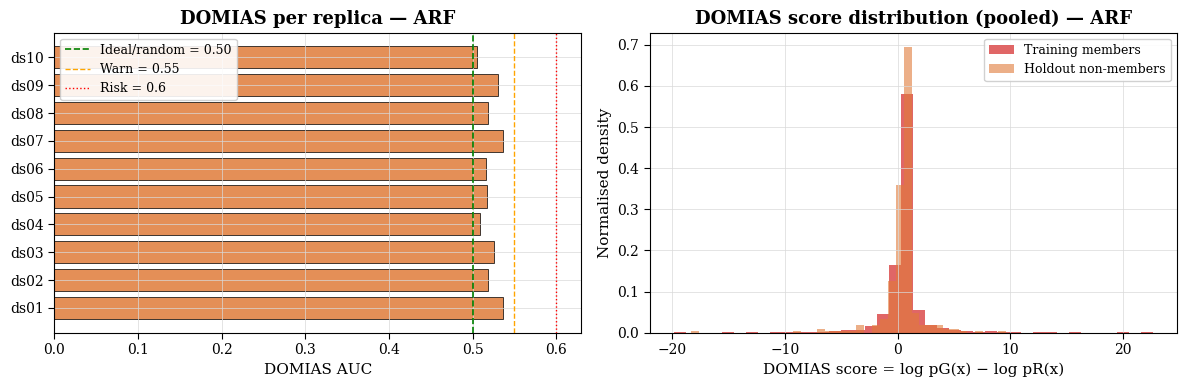

In [ ]:
# ── DOMIAS — DENSITY-RATIO MEMBERSHIP INFERENCE ATTACK ───────────────────────
# PURPOSE: Evaluate whether the synthetic distribution reveals membership
#          information by detecting local overfitting.
#
# Correct DOMIAS scoring uses a density ratio, not synthetic density alone:
#      score(x) = log p_G(x) - log p_R(x)
# where p_G is estimated from the released synthetic data and p_R from an
# independent real reference distribution. Here p_R is estimated from a split of
# dataset_TEST.csv, and membership is evaluated on training records vs. held-out
# non-member records.
#
# REFERENCE: van Breugel et al. 2023 (DOMIAS); Qian et al. 2024 [N4A].

assert 'X_holdout' in globals(), "X_holdout not found. Run 1 Data Loading first."
assert len(X_holdout) > 0, "X_holdout is empty; DOMIAS requires a non-member reference."


def _kde_bandwidth(X):
    """Scott's rule of thumb with a safe lower bound for scaled data.

    Returns ``max(n ** (-1 / (d + 4)), 1e-3)`` so that KDE bandwidth never
    collapses to zero for very high-dimensional or very small samples.

    Parameters
    ----------
    X : np.ndarray
        Scaled feature matrix.

    Returns
    -------
    float
        Bandwidth for ``sklearn.neighbors.KernelDensity``.
    """
    n, d = X.shape
    bw = n ** (-1.0 / (d + 4))
    return max(float(bw), 1e-3)


def split_domias_reference(X_holdout, ref_fraction=DOMIAS_REF_FRACTION,
                           random_state=42):
    """Split the holdout into a density reference and an evaluation set.

    The DOMIAS density-ratio attack needs two independent slices of the real
    holdout: one for estimating ``p_R`` and another to use as non-members
    when computing AUROC. When the holdout is too small (< 50 records), the
    function falls back to reusing the full holdout for both steps and prints
    a warning. For this dataset the exported ``dataset_TEST.csv`` is large
    enough to split.

    Parameters
    ----------
    X_holdout : np.ndarray
        Scaled real held-out matrix.
    ref_fraction : float, default ``DOMIAS_REF_FRACTION``
        Fraction of ``X_holdout`` assigned to the density reference.
    random_state : int, default 42
        Reproducibility seed for the split.

    Returns
    -------
    X_ref_density : np.ndarray
        Records used to estimate ``p_R``.
    X_nonmember_eval : np.ndarray
        Records used as non-members in the AUROC evaluation.
    """
    if len(X_holdout) < 50:
        print('!! WARNING: holdout too small for DOMIAS split; reusing full holdout for p_R and evaluation.')
        return X_holdout, X_holdout

    X_ref_density, X_nonmember_eval = train_test_split(
        X_holdout,
        train_size=ref_fraction,
        random_state=random_state,
        shuffle=True
    )
    return X_ref_density, X_nonmember_eval


X_ref_density, X_nonmember_eval = split_domias_reference(X_holdout)
print('DOMIAS reference split:')
print(f'  X_real members       : {X_real.shape}')
print(f'  X_ref_density for pR : {X_ref_density.shape}')
print(f'  X_nonmember_eval     : {X_nonmember_eval.shape}')


def compute_domias(X_synth, X_train_eval, X_nonmember_eval, X_ref_density):
    """Compute the DOMIAS density-ratio membership inference AUC.

    Fits a Gaussian KDE on the synthetic data (``p_G``) and on the independent
    real density reference (``p_R``). For every record in ``X_train_eval`` and
    ``X_nonmember_eval`` the score ``log p_G(x) - log p_R(x)`` is computed,
    and AUROC is evaluated with training members as positives and held-out
    records as negatives.

    Parameters
    ----------
    X_synth : np.ndarray
        Scaled synthetic data used to estimate ``p_G``.
    X_train_eval : np.ndarray
        Scaled real training records (members) scored under the attack.
    X_nonmember_eval : np.ndarray
        Scaled real held-out records (non-members) scored under the attack.
    X_ref_density : np.ndarray
        Independent real holdout slice used to estimate ``p_R``.

    Returns
    -------
    domias_auc : float
        AUROC for member vs non-member separation under the density-ratio
        score. ``0.5`` means no membership signal.
    scores_tr : np.ndarray
        Per-record scores for the training members.
    scores_ho : np.ndarray
        Per-record scores for the held-out non-members.
    """
    kde_g = KernelDensity(
        kernel='gaussian',
        bandwidth=_kde_bandwidth(X_synth),
        algorithm='ball_tree'
    )
    kde_r = KernelDensity(
        kernel='gaussian',
        bandwidth=_kde_bandwidth(X_ref_density),
        algorithm='ball_tree'
    )

    kde_g.fit(X_synth)
    kde_r.fit(X_ref_density)

    scores_tr = kde_g.score_samples(X_train_eval)    - kde_r.score_samples(X_train_eval)
    scores_ho = kde_g.score_samples(X_nonmember_eval) - kde_r.score_samples(X_nonmember_eval)

    labels = np.array([1] * len(scores_tr) + [0] * len(scores_ho))
    scores = np.concatenate([scores_tr, scores_ho])

    return roc_auc_score(labels, scores), scores_tr, scores_ho


def domias_status(auc):
    """Map a DOMIAS AUC value to a status label.

    Parameters
    ----------
    auc : float
        DOMIAS AUC for a replica or for the pooled synthetic dataset.

    Returns
    -------
    str
        ``'RISK'`` if ``auc > DOMIAS_RISK_THR``, ``'WARN'`` if
        ``auc > DOMIAS_WARN_THR``, ``'OK'`` otherwise.
    """
    if auc > DOMIAS_RISK_THR:
        return 'RISK'
    if auc > DOMIAS_WARN_THR:
        return 'WARN'
    return 'OK'


# ── Per-replica evaluation ────────────────────────────────────────────────────
domias_records = []
for key, df_s in replicas.items():
    X_s = scaler.transform(imp.transform(df_s[AVAIL_FEATURES]))
    auc, _, _ = compute_domias(X_s, X_real, X_nonmember_eval, X_ref_density)
    status = domias_status(auc)
    print(f"  {key}: DOMIAS AUC = {auc:.4f}  [{status}]")
    domias_records.append({'replica': key, 'DOMIAS_AUC': auc})

# ── Pooled evaluation ─────────────────────────────────────────────────────────
auc_pool, scores_tr_pool, scores_ho_pool = compute_domias(
    X_synth_all, X_real, X_nonmember_eval, X_ref_density
)
status_pool = domias_status(auc_pool)
print(f"\nPooled DOMIAS AUC: {auc_pool:.4f}  [{status_pool}]")
print(f"(Ideal ≈ 0.50; warn > {DOMIAS_WARN_THR}; risk > {DOMIAS_RISK_THR})")

domias_df = pd.DataFrame(domias_records)
domias_df.loc[len(domias_df)] = {'replica': 'POOLED', 'DOMIAS_AUC': auc_pool}
domias_df.to_csv(os.path.join(OUTPUT_DIR, 'domias.csv'), index=False)

domias_auc_vals = domias_df[domias_df['replica'] != 'POOLED']['DOMIAS_AUC'].values
print(f"\nDOMIAS AUC mean ± SD : {domias_auc_vals.mean():.4f} ± {domias_auc_vals.std():.4f}")
print(f"DOMIAS AUC range     : [{domias_auc_vals.min():.4f}, {domias_auc_vals.max():.4f}]")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: per-replica AUC bar chart
per_rep = domias_df[domias_df['replica'] != 'POOLED']
axes[0].barh(per_rep['replica'], per_rep['DOMIAS_AUC'],
             color=TFG_COLORS[GENERATOR], edgecolor='black',
             linewidth=0.6, alpha=0.85)
axes[0].axvline(0.5,              color='green', linestyle='--', linewidth=1.2,
                label='Ideal/random = 0.50')
axes[0].axvline(DOMIAS_WARN_THR,  color='orange', linestyle='--', linewidth=1.0,
                label=f'Warn = {DOMIAS_WARN_THR}')
axes[0].axvline(DOMIAS_RISK_THR,  color='red', linestyle=':', linewidth=1.0,
                label=f'Risk = {DOMIAS_RISK_THR}')
axes[0].set_xlabel('DOMIAS AUC')
axes[0].set_title(f'DOMIAS per replica — {GENERATOR}')
axes[0].legend()

# Right: density-ratio score distributions (pooled)
axes[1].hist(scores_tr_pool, bins=40, alpha=0.6,
             color=TFG_COLORS['real'],    label='Training members', density=True)
axes[1].hist(scores_ho_pool, bins=40, alpha=0.6,
             color=TFG_COLORS[GENERATOR], label='Holdout non-members', density=True)
axes[1].set_xlabel('DOMIAS score = log pG(x) − log pR(x)')
axes[1].set_ylabel('Normalised density')
axes[1].set_title(f'DOMIAS score distribution (pooled) — {GENERATOR}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'domias.png'), dpi=150)
plt.show()


## **9. Authenticity and Near-Duplicate Detection**

**Authenticity** [Alaa et al. (2022); Vallevik et al. 2024, N3A; Qian et al.
2024, N4A] complements NND/NNDR by checking whether synthetic records are so
close to real training records that they effectively constitute near-copies.

A synthetic record is flagged as a **near-duplicate** if its nearest-real
distance is less than or equal to a data-driven threshold.

### Threshold choice

The previous implementation used the raw 5th percentile of real-to-real NND.
If the real data contain exact duplicates or ties, that percentile can become
zero and the detector becomes non-informative.

This notebook uses:

$$\tau = P_5\left(\text{real-to-real NND} \mid \text{NND} > 0\right)$$

That is: the 5th percentile of the **strictly positive** real-to-real nearest
neighbour distances.

This is the recommended threshold here because it is:

- data-driven and scale-free,
- robust to duplicate/tied real records,
- conservative enough for near-copy detection,
- consistent with the idea of comparing synthetic closeness against natural
  closeness among real records.

### Interpretation

- **Near-duplicate rate ≈ 0 %**: no evidence of memorised individual records.
- **Near-duplicate rate > 5 %**: potential overfitting or privacy risk.
- **Authenticity = 1 − near-duplicate rate**.
- **Authenticity ≥ 0.95**: pass threshold.

### Relation to Linkability

These two metrics capture complementary risks:

| Metric | Measures | What passes |
|--------|----------|-------------|
| Authenticity | Whether synthetic records are near-copies of real records | Near-dup rate < 5% |
| Linkability | Whether synthetic QID combinations uniquely point to real individuals | Link rate < 5% |

A generator can produce high authenticity but still have elevated linkability,
so both metrics are retained.


Near-duplicate threshold: 0.626759 (5th percentile of positive real-to-real NND)
Real-to-real NND zeros/ties ignored: 37 (positive reference n=463)

  ds01: near-dup =   11/1781 (0.62%) | Auth = 0.9938  [OK]
  ds02: near-dup =    6/1781 (0.34%) | Auth = 0.9966  [OK]
  ds03: near-dup =   10/1781 (0.56%) | Auth = 0.9944  [OK]
  ds04: near-dup =   15/1781 (0.84%) | Auth = 0.9916  [OK]
  ds05: near-dup =    5/1781 (0.28%) | Auth = 0.9972  [OK]
  ds06: near-dup =    4/1781 (0.22%) | Auth = 0.9978  [OK]
  ds07: near-dup =    7/1781 (0.39%) | Auth = 0.9961  [OK]
  ds08: near-dup =    9/1781 (0.51%) | Auth = 0.9949  [OK]
  ds09: near-dup =   10/1781 (0.56%) | Auth = 0.9944  [OK]
  ds10: near-dup =    6/1781 (0.34%) | Auth = 0.9966  [OK]

Mean near-duplicate rate : 0.47%
Mean authenticity        : 0.9953


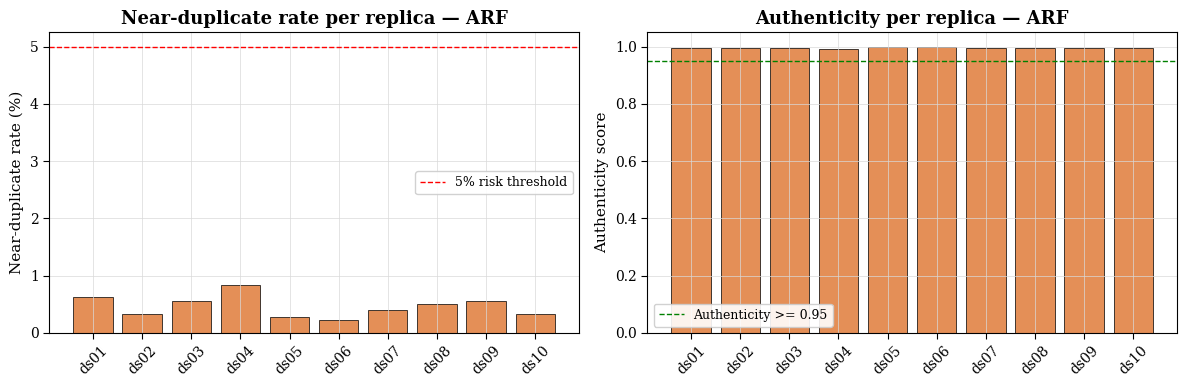

In [ ]:
# ── AUTHENTICITY / NEAR-DUPLICATE DETECTION ───────────────────────────────────
# PURPOSE: Identify synthetic records that are near-copies of real training
#          records.
#
# DEPENDENCY: Requires tree_real_full and nnd_real_ref from 4 NND/NNDR.
#             Both cells must be executed in order.
#
# THRESHOLD: NEARDUP_PERCENTILE-th percentile of the strictly positive
#            real-to-real NND distribution. This avoids the degenerate
#            threshold = 0 problem caused by exact duplicates/ties in the real
#            data.
#
# REFERENCE: Alaa et al. (2022); Vallevik et al. 2024 [N3A]; Qian et al. [N4A].

# ── Defensive check for NND/NNDR dependency ───────────────────────────────────
assert 'tree_real_full' in globals(), (
    "tree_real_full not found. Run the NND/NNDR cell first."
)
assert 'nnd_real_ref' in globals(), (
    "nnd_real_ref not found. Run the NND/NNDR cell first."
)


def positive_percentile_threshold(values, percentile=5, eps=1e-12):
    """
    Percentile threshold using only positive distances.

    If the real-to-real reference includes exact duplicates, the raw 5th
    percentile can be zero and the near-duplicate detector becomes useless.
    Using positive distances keeps the threshold data-driven while making the
    test informative.
    """
    values = np.asarray(values, dtype=float)
    positive = values[values > eps]

    n_zero = int((values <= eps).sum())
    if len(positive) == 0:
        raise ValueError('All real-to-real NND values are zero; cannot define a positive threshold.')

    thr = np.percentile(positive, percentile)
    return max(float(thr), eps), n_zero, len(positive)


# ── Compute near-duplicate threshold ──────────────────────────────────────────
neardup_thr, n_zero_ref, n_positive_ref = positive_percentile_threshold(
    nnd_real_ref, NEARDUP_PERCENTILE
)
print(f"Near-duplicate threshold: {neardup_thr:.6f} "
      f"({NEARDUP_PERCENTILE}th percentile of positive real-to-real NND)")
print(f"Real-to-real NND zeros/ties ignored: {n_zero_ref} "
      f"(positive reference n={n_positive_ref})\n")

# ── Per-replica authenticity ──────────────────────────────────────────────────
auth_records = []
for key, df_s in replicas.items():
    X_s = scaler.transform(imp.transform(df_s[AVAIL_FEATURES]))
    dists_s, _ = tree_real_full.query(X_s, k=1)
    nnd_s      = dists_s[:, 0]

    # <= so that records at the data-driven threshold are conservatively flagged.
    near_dup_n = int((nnd_s <= neardup_thr).sum())
    near_dup_r = near_dup_n / len(nnd_s)
    auth_score = 1.0 - near_dup_r

    status = 'OK' if near_dup_r < 0.05 else 'RISK'
    print(f"  {key}: near-dup = {near_dup_n:>4d}/{len(nnd_s)} "
          f"({near_dup_r*100:.2f}%) | Auth = {auth_score:.4f}  [{status}]")

    auth_records.append({
        'replica':       key,
        'n_total':       len(nnd_s),
        'n_near_dup':    near_dup_n,
        'near_dup_rate': near_dup_r,
        'authenticity':  auth_score,
        'neardup_threshold': neardup_thr,
        'real_ref_zero_nnd': n_zero_ref,
    })

auth_df = pd.DataFrame(auth_records)
print(f"\nMean near-duplicate rate : {auth_df['near_dup_rate'].mean()*100:.2f}%")
print(f"Mean authenticity        : {auth_df['authenticity'].mean():.4f}")

auth_df.to_csv(os.path.join(OUTPUT_DIR, 'authenticity.csv'), index=False)

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(auth_df['replica'], auth_df['near_dup_rate'] * 100,
            color=TFG_COLORS[GENERATOR], edgecolor='black',
            linewidth=0.6, alpha=0.85)
axes[0].axhline(5, color='red', linestyle='--', linewidth=1,
               label='5% risk threshold')
axes[0].set_ylabel('Near-duplicate rate (%)')
axes[0].set_title(f'Near-duplicate rate per replica — {GENERATOR}')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(auth_df['replica'], auth_df['authenticity'],
            color=TFG_COLORS[GENERATOR], edgecolor='black',
            linewidth=0.6, alpha=0.85)
axes[1].axhline(0.95, color='green', linestyle='--', linewidth=1,
               label='Authenticity >= 0.95')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Authenticity score')
axes[1].set_title(f'Authenticity per replica — {GENERATOR}')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'authenticity.png'), dpi=150)
plt.show()


## **10. Comprehensive Privacy Summary**

All privacy metrics are consolidated into a single summary table and a radar
chart for visual comparison. The radar chart maps each metric to a normalised
[0, 1] scale where 1 = best privacy.

The final privacy assessment is **multi-metric**. K-anonymity is included as one
re-identification descriptor, but it is not treated as a sufficient privacy
guarantee by itself.

The radar chart uses six dimensions:

1. K-anonymity
2. NNAA
3. NND ratio
4. Linkability
5. Authenticity
6. DOMIAS

Membership Disclosure is retained in the exported summary table because its
scale is not naturally comparable to the other radar axes.



Privacy Summary — ARF
  Generator                               : ARF
  n_real_train                            : 1781
  n_real_holdout                          : 595
  n_synth_per_replica                     : 1781
  k_min_mean                              : 1.0000
  k_min_min                               : 1.0000
  NNAA_mean                               : 0.4141
  NNAA_max                                : 0.4290
  NNAA_interpretation                     : OK
  NND_synth_mean                          : 1.7209
  NND_real_ref_mean                       : 1.2292
  NNDR_mean                               : 0.9234
  near_copy_rate_mean_pct                 : 0.0400
  Membership_F1_pooled                    : 0.0000
  Membership_F1_naive                     : 0.0026
  Membership_Frel_pooled                  : -0.0026
  Membership_Frel_pass                    : True
  linkability_rate_mean_pct               : 9.1000
  linkability_rate_max_pct                : 10.4000
  DOMIAS_AUC_mean     

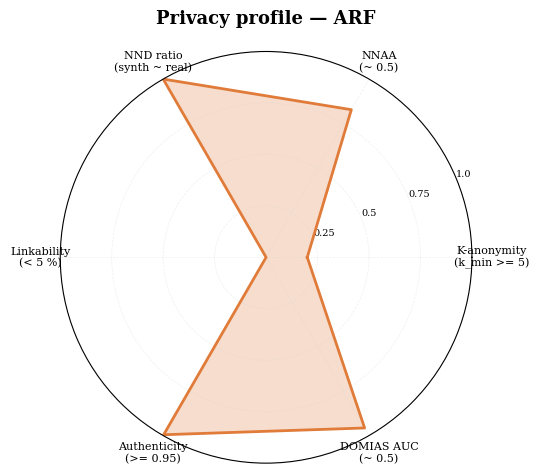

In [ ]:
# ── PRIVACY SUMMARY TABLE ─────────────────────────────────────────────────────
# PURPOSE: Consolidate all privacy metrics into a single summary for this
#          generator. Exports a CSV usable for cross-generator comparison.
#
# NOTE: K-anonymity is retained as one re-identification descriptor, but the
#       privacy decision is not based on K-anonymity alone. The summary combines
#       membership disclosure, DOMIAS, NNAA, NND/NNDR, linkability and
#       authenticity.

privacy_summary = {
    'Generator':               GENERATOR,
    'n_real_train':            len(df_real),
    'n_real_holdout':          len(df_holdout),
    'n_synth_per_replica':     int(np.median([len(v) for v in replicas.values()])),
    'k_min_mean':              kanon_df['k_min'].mean(),
    'k_min_min':               kanon_df['k_min'].min(),
    'NNAA_mean':               nnaa_vals.mean(),
    'NNAA_max':                nnaa_vals.max(),
    'NNAA_interpretation':     ('PRIVACY_RISK' if nnaa_vals.mean() > NNAA_RISK_THR else
                                'FIDELITY_WARNING' if nnaa_vals.mean() < NNAA_LOW_THR else 'OK'),
    'NND_synth_mean':          nnd_all_synth.mean(),
    'NND_real_ref_mean':       nnd_real_ref.mean(),
    'NNDR_mean':               nndr_all_synth.mean(),
    'near_copy_rate_mean_pct': nnd_summary['near_copy_rate'].mean() * 100,
    'Membership_F1_pooled':    f1_att_pool,
    'Membership_F1_naive':     f1_nai_pool,
    'Membership_Frel_pooled':  f1_rel_pool,
    'Membership_Frel_pass':    f1_rel_pool <= MD_THRESHOLD,
    'linkability_rate_mean_pct': link_df['link_rate'].mean() * 100,
    'linkability_rate_max_pct':  link_df['link_rate'].max() * 100,
    'DOMIAS_AUC_mean':         domias_auc_vals.mean(),
    'DOMIAS_AUC_pooled':       float(domias_df.loc[domias_df['replica'] == 'POOLED',
                                                   'DOMIAS_AUC'].values[0]),
    'authenticity_mean':       auth_df['authenticity'].mean(),
    'near_dup_rate_mean_pct':  auth_df['near_dup_rate'].mean() * 100,
    'near_dup_threshold':      float(auth_df['neardup_threshold'].iloc[0]),
}

summary_path = os.path.join(OUTPUT_DIR, 'privacy_summary.csv')
pd.Series(privacy_summary).to_csv(summary_path)

print(f"\nPrivacy Summary — {GENERATOR}")
print("=" * 55)
for k, v in privacy_summary.items():
    if isinstance(v, float):
        print(f"  {k:40s}: {v:.4f}")
    else:
        print(f"  {k:40s}: {v}")
print(f"\nSaved to: {summary_path}")

# ── Radar / spider chart (6 axes) ─────────────────────────────────────────────
# Normalisation: each dimension mapped to [0, 1] where 1 = best privacy.
metrics_radar = {
    'K-anonymity\n(k_min >= 5)':     min(1.0, kanon_df['k_min'].mean() / 5),
    'NNAA\n(~ 0.5)':                 max(0.0, 1.0 - 2 * abs(nnaa_vals.mean() - 0.5)),
    'NND ratio\n(synth ~ real)':     min(1.0, nnd_all_synth.mean() /
                                          (nnd_real_ref.mean() + 1e-12)),
    'Linkability\n(< 5 %)':          max(0.0, 1.0 - link_df['link_rate'].mean() / 0.05),
    'Authenticity\n(>= 0.95)':       auth_df['authenticity'].mean(),
    'DOMIAS AUC\n(~ 0.5)':           max(0.0, 1.0 - 2 * abs(domias_auc_vals.mean() - 0.5)),
}

labels = list(metrics_radar.keys())
vals   = list(metrics_radar.values())
vals  += vals[:1]                               # close polygon
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(5.5, 5.5), subplot_kw=dict(polar=True))
ax.plot(angles, vals, color=TFG_COLORS[GENERATOR], linewidth=2)
ax.fill(angles, vals, color=TFG_COLORS[GENERATOR], alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=8)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['0.25', '0.5', '0.75', '1.0'], size=7)
ax.set_title(f'Privacy profile — {GENERATOR}', pad=20)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'privacy_radar.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## **11. Conclusions and Interpretation**

Results are consolidated in `privacy_summary.csv` and per-metric CSV files.

### Interpretation thresholds

| Metric | Acceptable / Ideal | Warning | Risk |
|--------|--------------------|---------|------|
| k_min | ≥ 5 | 3–4 | < 3 |
| NNAA bidirectional | ≈ 0.50 | < 0.40 = fidelity warning | > 0.60 = privacy risk |
| NNDR near-copy rate | < 1 % | 1–5 % | > 5 % |
| Membership Disclosure `F_rel` | ≤ 0.20 | — | > 0.20 |
| Linkability rate | < 5 % | 5–10 % | > 10 % |
| DOMIAS AUC | ≈ 0.50 | > 0.55 | > 0.60 |
| Authenticity | ≥ 0.95 | 0.90–0.95 | < 0.90 |

For Membership Disclosure, negative `F_rel` values mean that the attacker did
not outperform the naive baseline and are interpreted as absence of measurable
membership advantage.

### Dataset references

- Synthetic replicas are compared against the **real training cohorts** in
  `cohorts/`, because those are the records seen by the generator.
- Membership Disclosure and DOMIAS additionally use **`dataset_TEST.csv`** as
  real non-member/holdout data.
- The full `dataset_FINAL.csv` is only a fallback for reconstruction and should
  not be the primary comparison dataset.

### Cross-generator comparison

1. Run with `GENERATOR = 'CTABGAN'`.
2. Run with `GENERATOR = 'ARF'`.
3. Merge both `privacy_summary.csv` files for a side-by-side table.

### Limitations

- **K-anonymity** is sensitive to QID choice and binning granularity. It is a
  useful descriptor, not a standalone privacy guarantee.
- **NNAA and NND** use balanced subsampling (n = `SUBSAMPLE_N`); results may
  vary slightly across runs due to sampling variability, although the seed is
  fixed.
- **Linkability** uses NNDR in QID-only space. Different QID assumptions would
  lead to different linkability rates.
- **Membership Disclosure** uses a binned Hamming matching rule. The default
  tolerance is strict (`MD_HAMMING_THRESHOLD = 1`); report a sensitivity check
  with thresholds 0, 1 and 2 if this becomes a central privacy claim.
- **DOMIAS** uses Gaussian KDE. In high-dimensional spaces, KDE is approximate;
  DOMIAS should be interpreted as an indicative black-box attack metric.
- **Authenticity** uses the 5th percentile of positive real-to-real distances.
  This fixes the zero-threshold problem while remaining data-driven.
